# K-Means Clustering


Laten we een voorbeeld doornemen van unsupervised learning - het clusteren van klantgegevens.

## Doel:
Wanneer we werken met methoden voor unsupervised learning, is het meestal belangrijk om een algemeen doel vast te stellen. In ons geval proberen we om clusters van klanten te vinden voor marktsegmentatie en -studie. Wat we uiteindelijk met die clusters doen, zou sterk afhangen van het domein zelf, in dit geval marketing.

----

## De gegevens Data

LINK: https://archive.ics.uci.edu/ml/datasets/bank+marketing

   Deze dataset is publiek beschikbaar voor research.  De details worden beschrveen in [Moro et al., 2011]. 


      [Moro et al., 2011] S. Moro, R. Laureano and P. Cortez. Using Data Mining for Bank Direct Marketing: An Application of the CRISP-DM Methodology. 
      In P. Novais et al. (Eds.), Proceedings of the European Simulation and Modelling Conference - ESM'2011, pp. 117-121, Guimarães, Portugal, October, 2011. EUROSIS.

      Beschikbaar via: [pdf] http://hdl.handle.net/1822/14838
                    [bib] http://www3.dsi.uminho.pt/pcortez/bib/2011-esm-1.txt
     Voor meer informatie: lees [Moro et al., 2011].

    # klantgegevens bank:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## Imports

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis

In [53]:
df = pd.read_csv("data/bank-full.csv")

In [54]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [55]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'subscribed'],
      dtype='object')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [57]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


### Continuous Feature Analysis

Dit is een bijzonder belangrijk onderdeel.  Het hebben van domeinkennis is onontbeerlijk bij unsupervised learning, omdat er geen labels zijn.  Doe dus indien je deze kennis nog niet hebt ofwel de nodige domeinkennis zelf op, of vraag informatie aan iemand die deze kennis heeft. Visualiseer ook de data goed om een goed idee te krijgen hoe deze eruitziet.

<Axes: xlabel='age', ylabel='Count'>

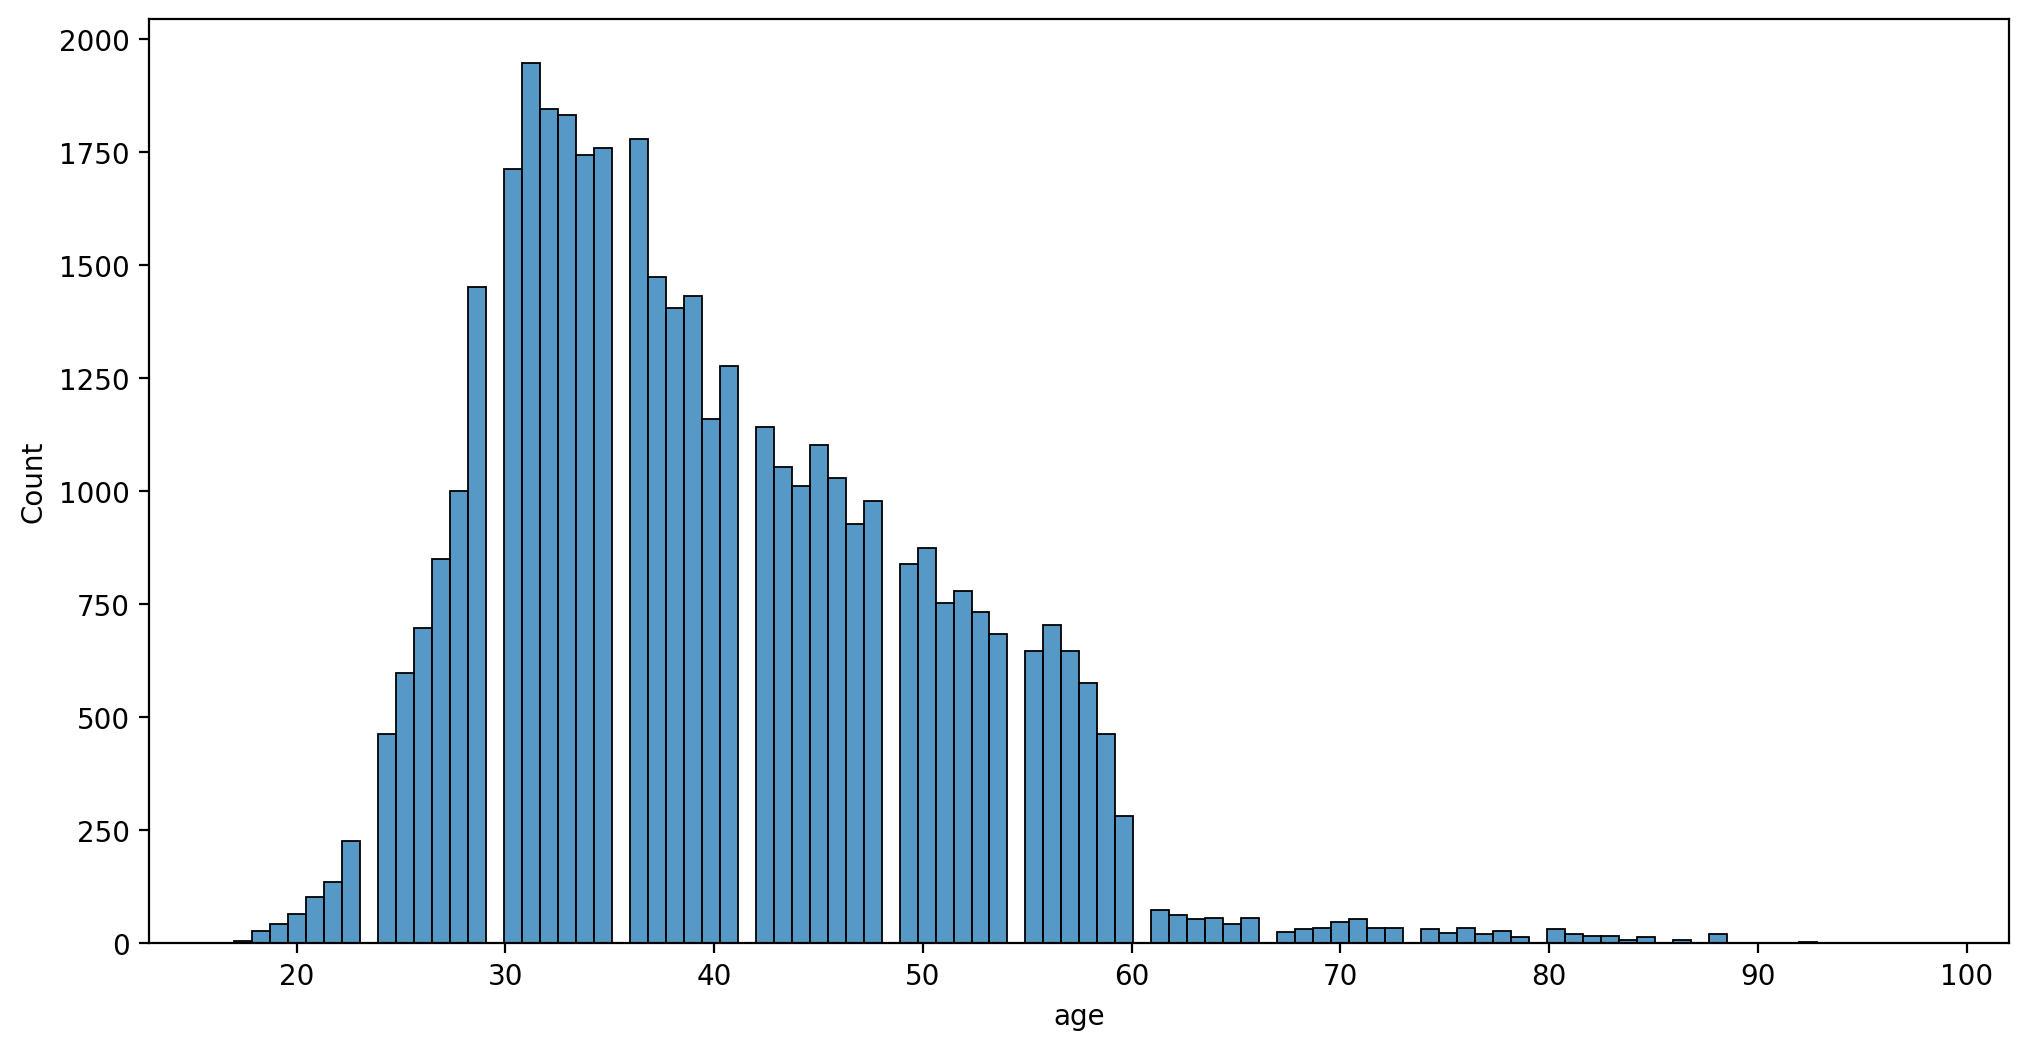

In [58]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='age')

meeste mensen zijn tussen dertig en veertig jaar oud!

In [59]:
# het lijkt alsof er geen mensen van vb 29 jaar oud in de dataset aanwezig zijn.  Dit klopt niet: 
twentyniners = df[df['age'] == 29]

In [60]:
# dit is nochtans niet het geval:
twentyniners.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
12,29,blue-collar,single,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
330,29,services,single,high.school,no,yes,no,telephone,may,mon,...,2,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
397,29,blue-collar,divorced,basic.4y,no,no,no,telephone,may,tue,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
473,29,admin.,married,university.degree,unknown,yes,no,telephone,may,tue,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
641,29,admin.,married,high.school,no,yes,no,telephone,may,tue,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


De reden dat dit zo is, is de automatische bin-bepaling: de automatische bin-bepaling kan resulteren in een bin-grootte die sommige waarden groepeert op een manier die niet intuïtief lijkt. Bijvoorbeeld, als de bin-grenzen vallen op 23.5 en 25.5 jaar, dan zullen alle 24-jarigen worden gegroepeerd met 25-jarigen, waardoor het lijkt alsof er geen 24-jarigen zijn.

Wanneer je expliciet een aantal 'bins' opgeeft, zoals 30, dwing je de plot om de data te verdelen over precies dat aantal bins, ongeacht de data-verdeling. Dit kan ervoor zorgen dat de visualisatie meer uniform lijkt en het effect van ontbrekende leeftijden verminderen, omdat elke bin een bereik van leeftijden bevat, waardoor de kans kleiner wordt dat een hele leeftijdsgroep wordt gemist.

<Axes: xlabel='age', ylabel='Count'>

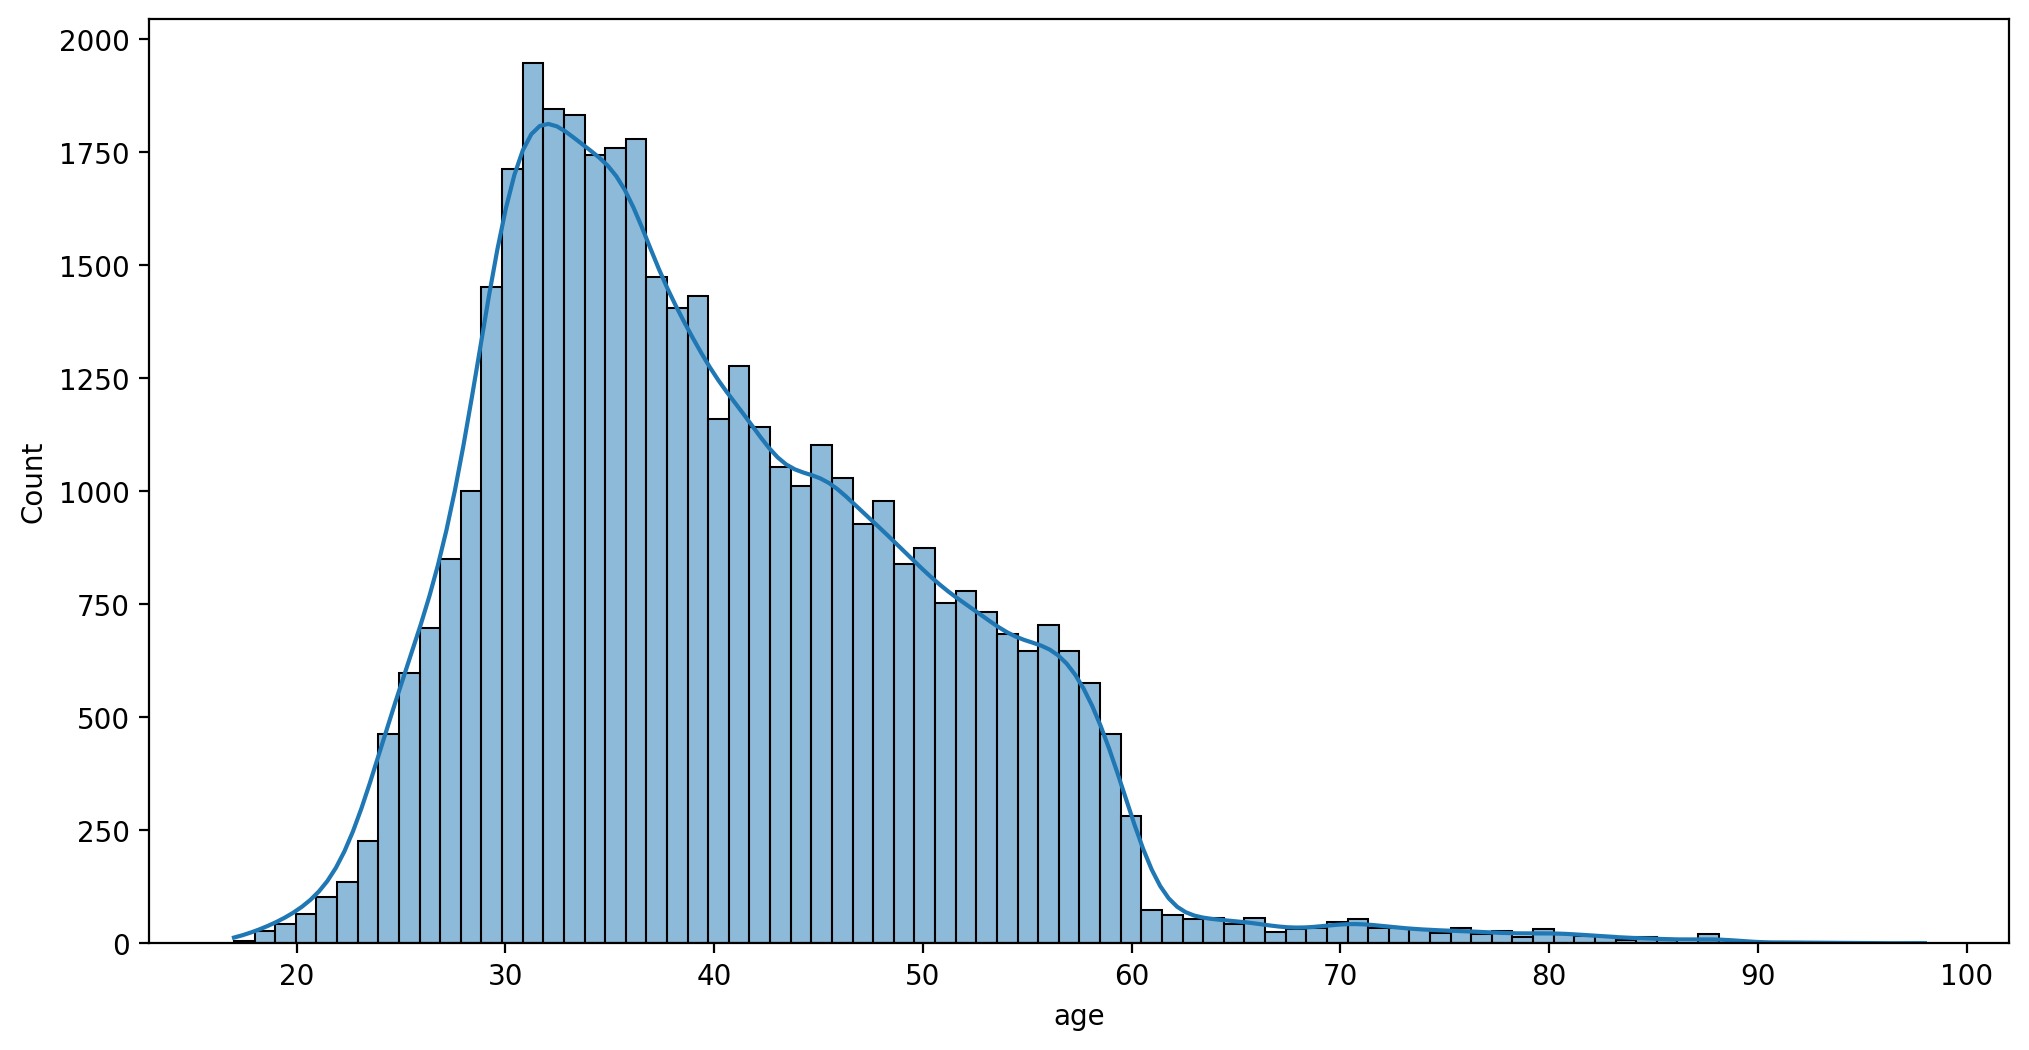

In [62]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='age', bins=82, kde=True)

Uit het histogram leren we dat de grootste groep waarnaar marketing wordt gedaan begin de 30 tot ongeveer 40 is.

Misschien is het al dan niet hebben van een lening interessant.  Zo zal je geen advertenties voor leningen doen naar mensen die al een lening hebben...

<Axes: xlabel='age', ylabel='Count'>

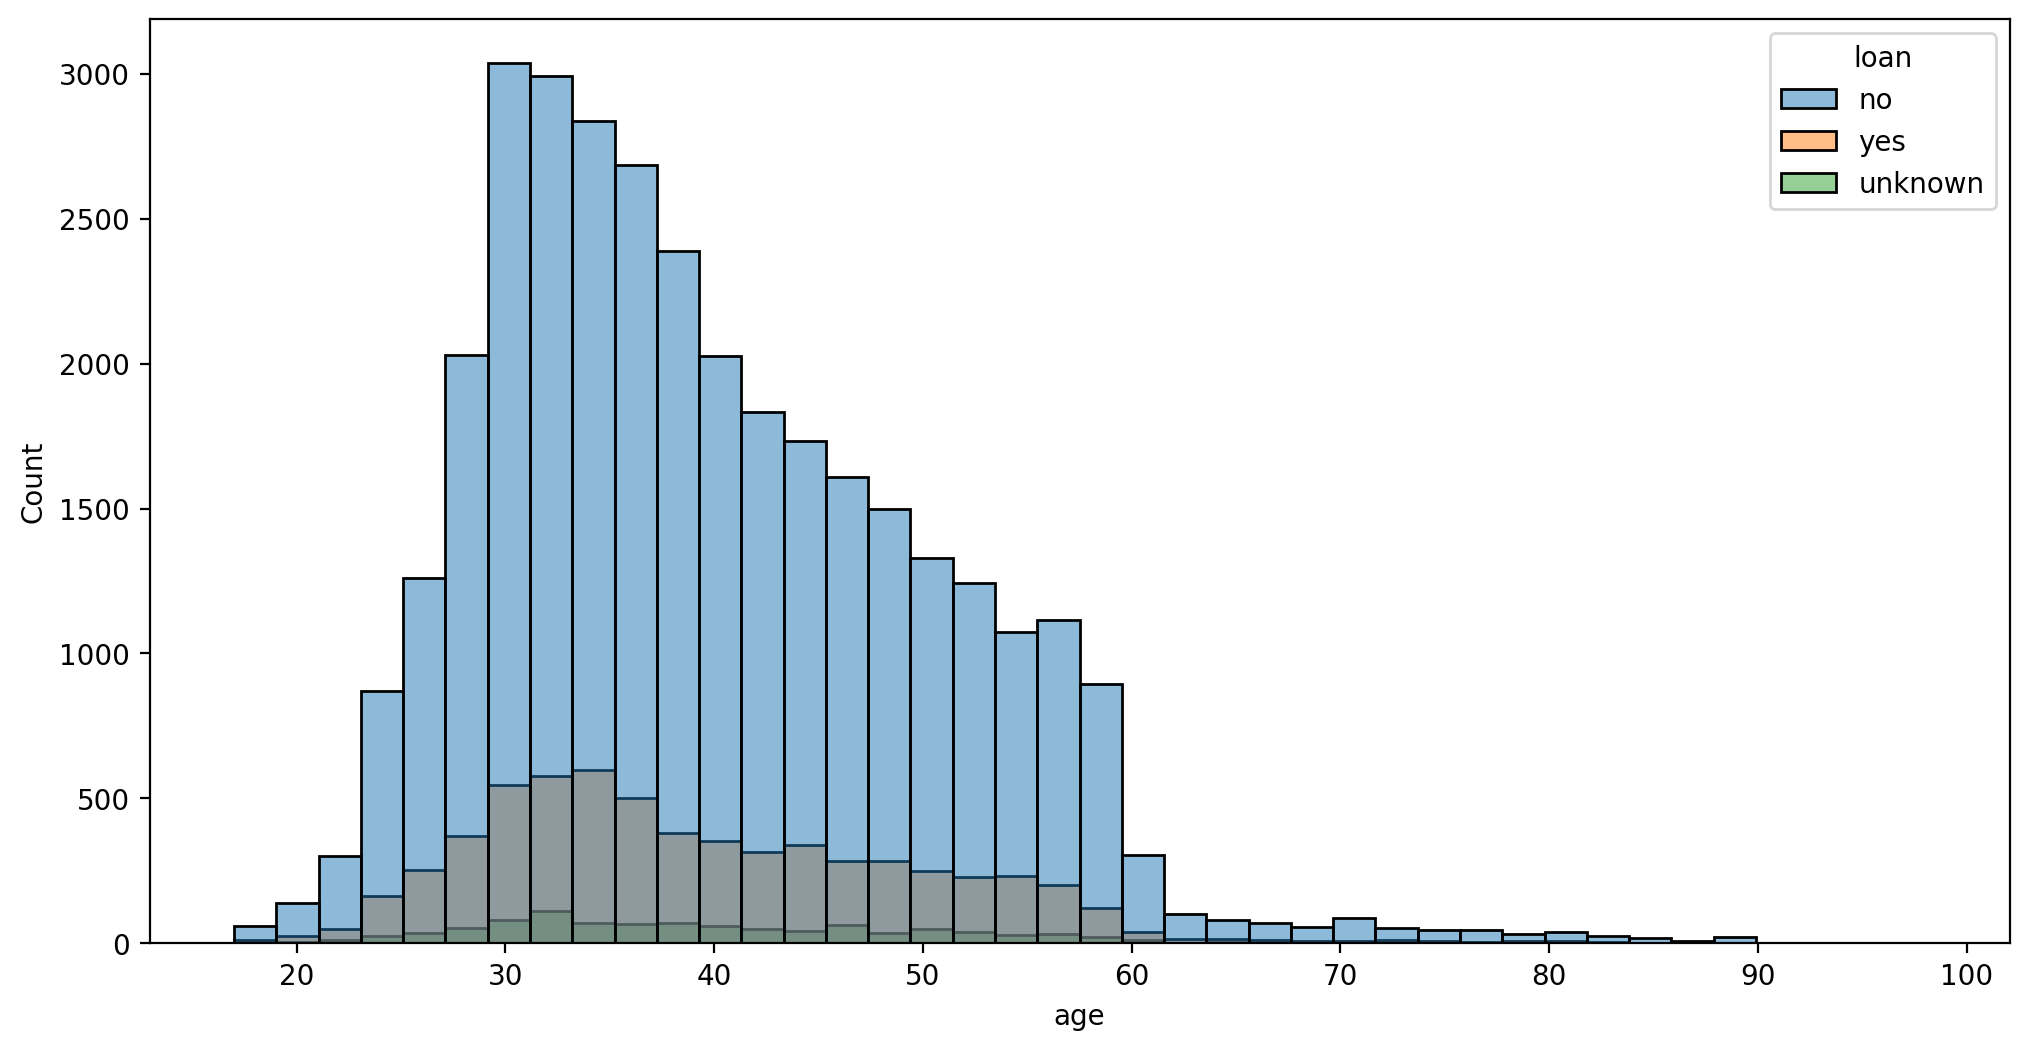

In [63]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='age',hue='loan', bins=40)

De meeste mensen hebben geen lening! Je zou vb alle mensen die geen lening hebben kunnen afsplitsen en daarop verder clusteren...  Sommige sectoren zullen zich net op mensen die wel al een lening hebben richten.

### pdays
Er is een feature (12) pdays die aangeeft hoeveel dagen voorbij zijn sinds de klant laatst werd gecontacteerd voor een vorige campagne.  999 betekent dat de klant nog nooit werd gecontacteerd!  Indien je dit niet weet en deze feature plot, dan krijg je iets onverwachts:

<Axes: xlabel='pdays', ylabel='Count'>

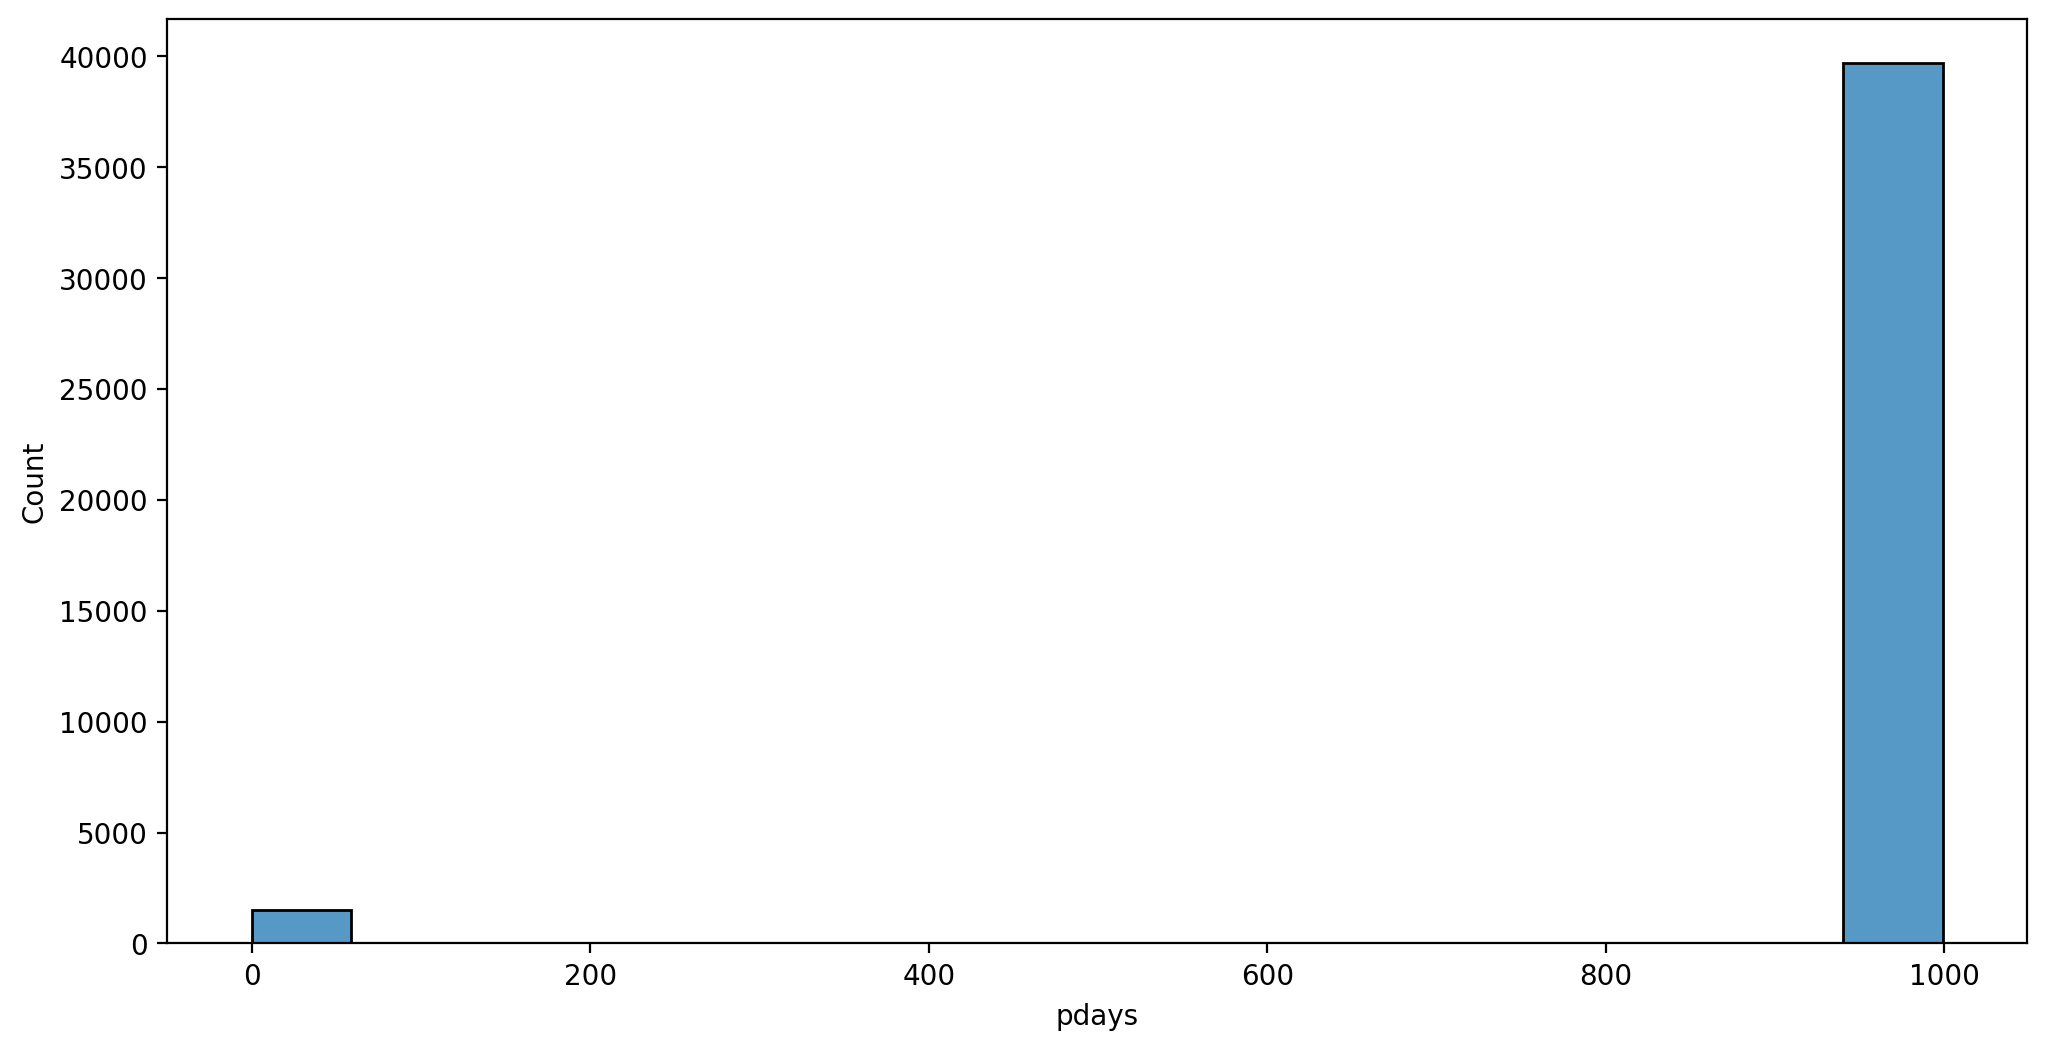

In [64]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='pdays')

Daarom is het interessanter om deze filler waarde niet mee te nemen in de plot:

<Axes: xlabel='pdays', ylabel='Count'>

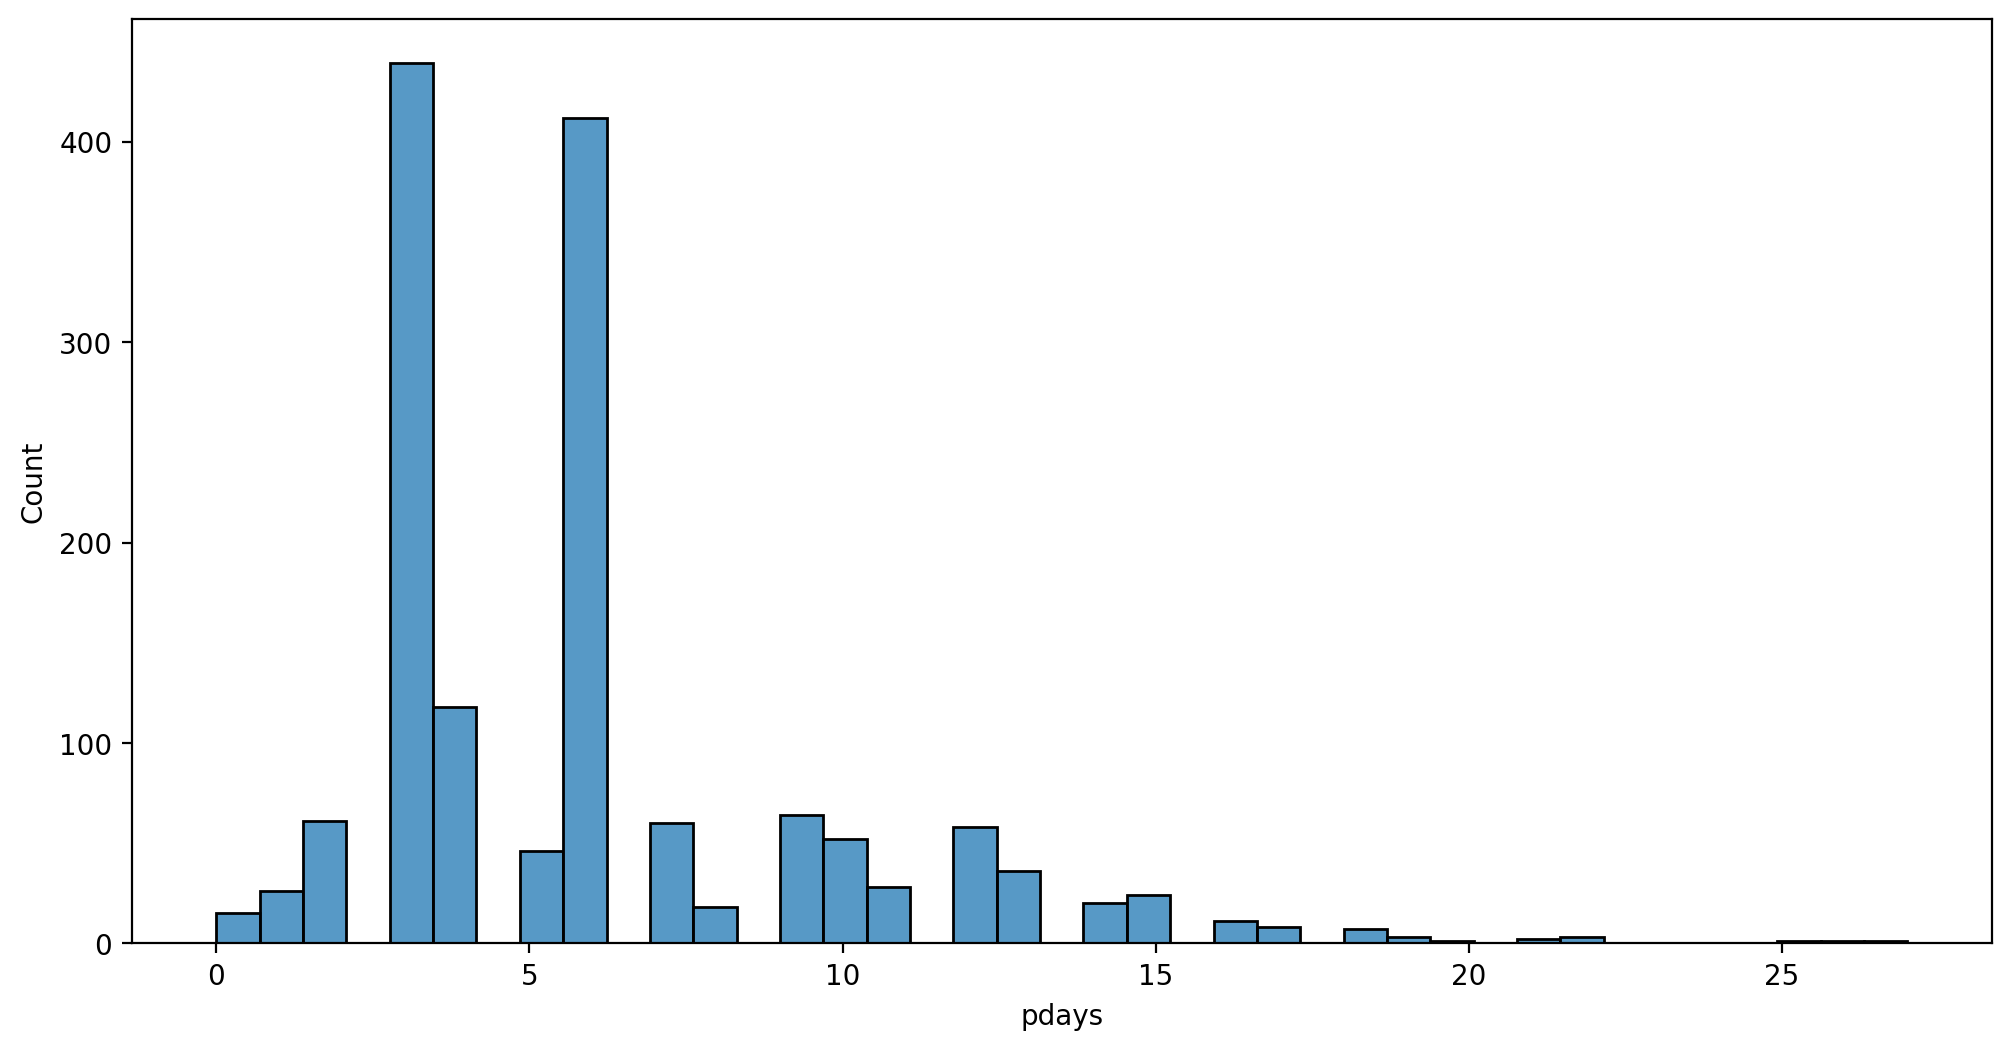

In [65]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df[df['pdays']!=999],x='pdays')

We zien dat van de mensen die werden gecontacteerd, dit voor de meesten niet zo lang is geleden.  We weten echter ook dat de meeste mensen nooit eerder werden gecontacteerd!

**Contact duration - wanneer er contact was met de klant, hoe lang duurde dit contact (in seconden)?**

In [66]:
# welke soorten contact zijn er?
df['contact'].unique()

array(['telephone', 'cellular'], dtype=object)

Dus contacteerden we hen op een vast of mobiel nummer?

(0.0, 2000.0)

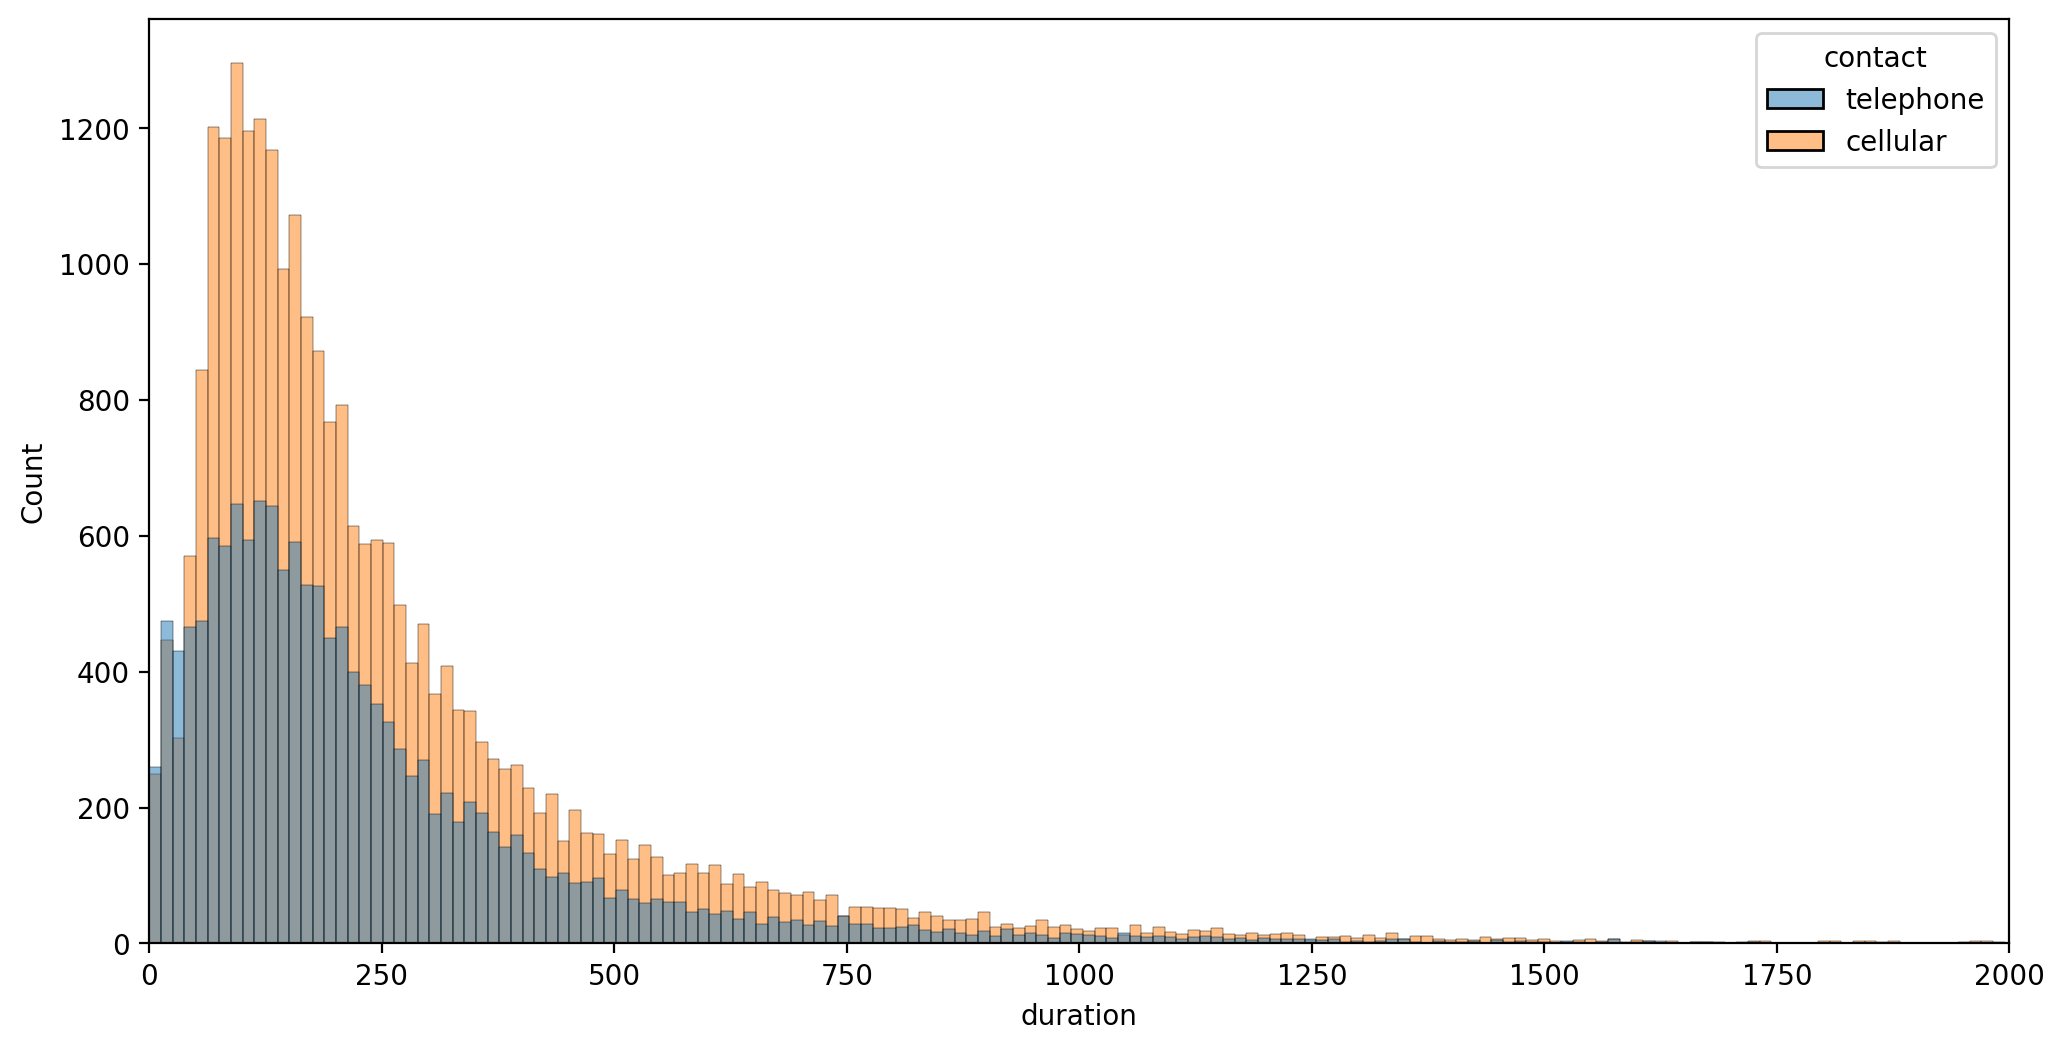

In [67]:
plt.figure(figsize=(12,6),dpi=200)
sns.histplot(data=df,x='duration',hue='contact')
plt.xlim(0,2000) # enkele gesprekken duurden heel erg lang...

Er zijn dus meer mensen die werden gecontacteerd via mobiel dan via vaste lijn, maar de vorm van de curve is gelijkaardig.  Ongeacht vast of mobiel duren de gesprekken dus even lang, maar er zijn gewoon meer mobiele gesprekken.

### Zijn er meer mensen op de GSM gecontacteerd?

<Axes: xlabel='contact', ylabel='count'>

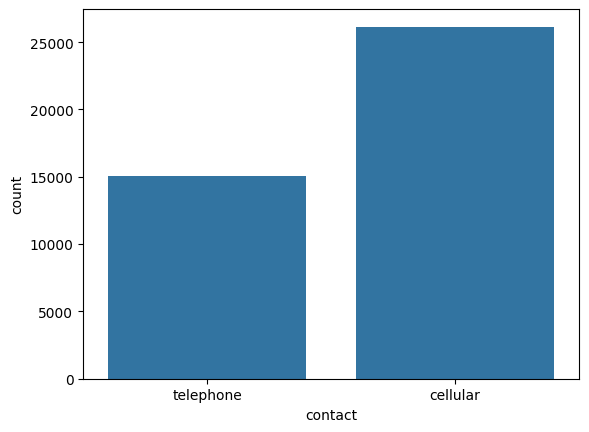

In [68]:
sns.countplot(data=df,x='contact')

* 15 - previous: number of contacts performed before this campaign and for this client (numeric)
* 16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

<Axes: xlabel='previous', ylabel='count'>

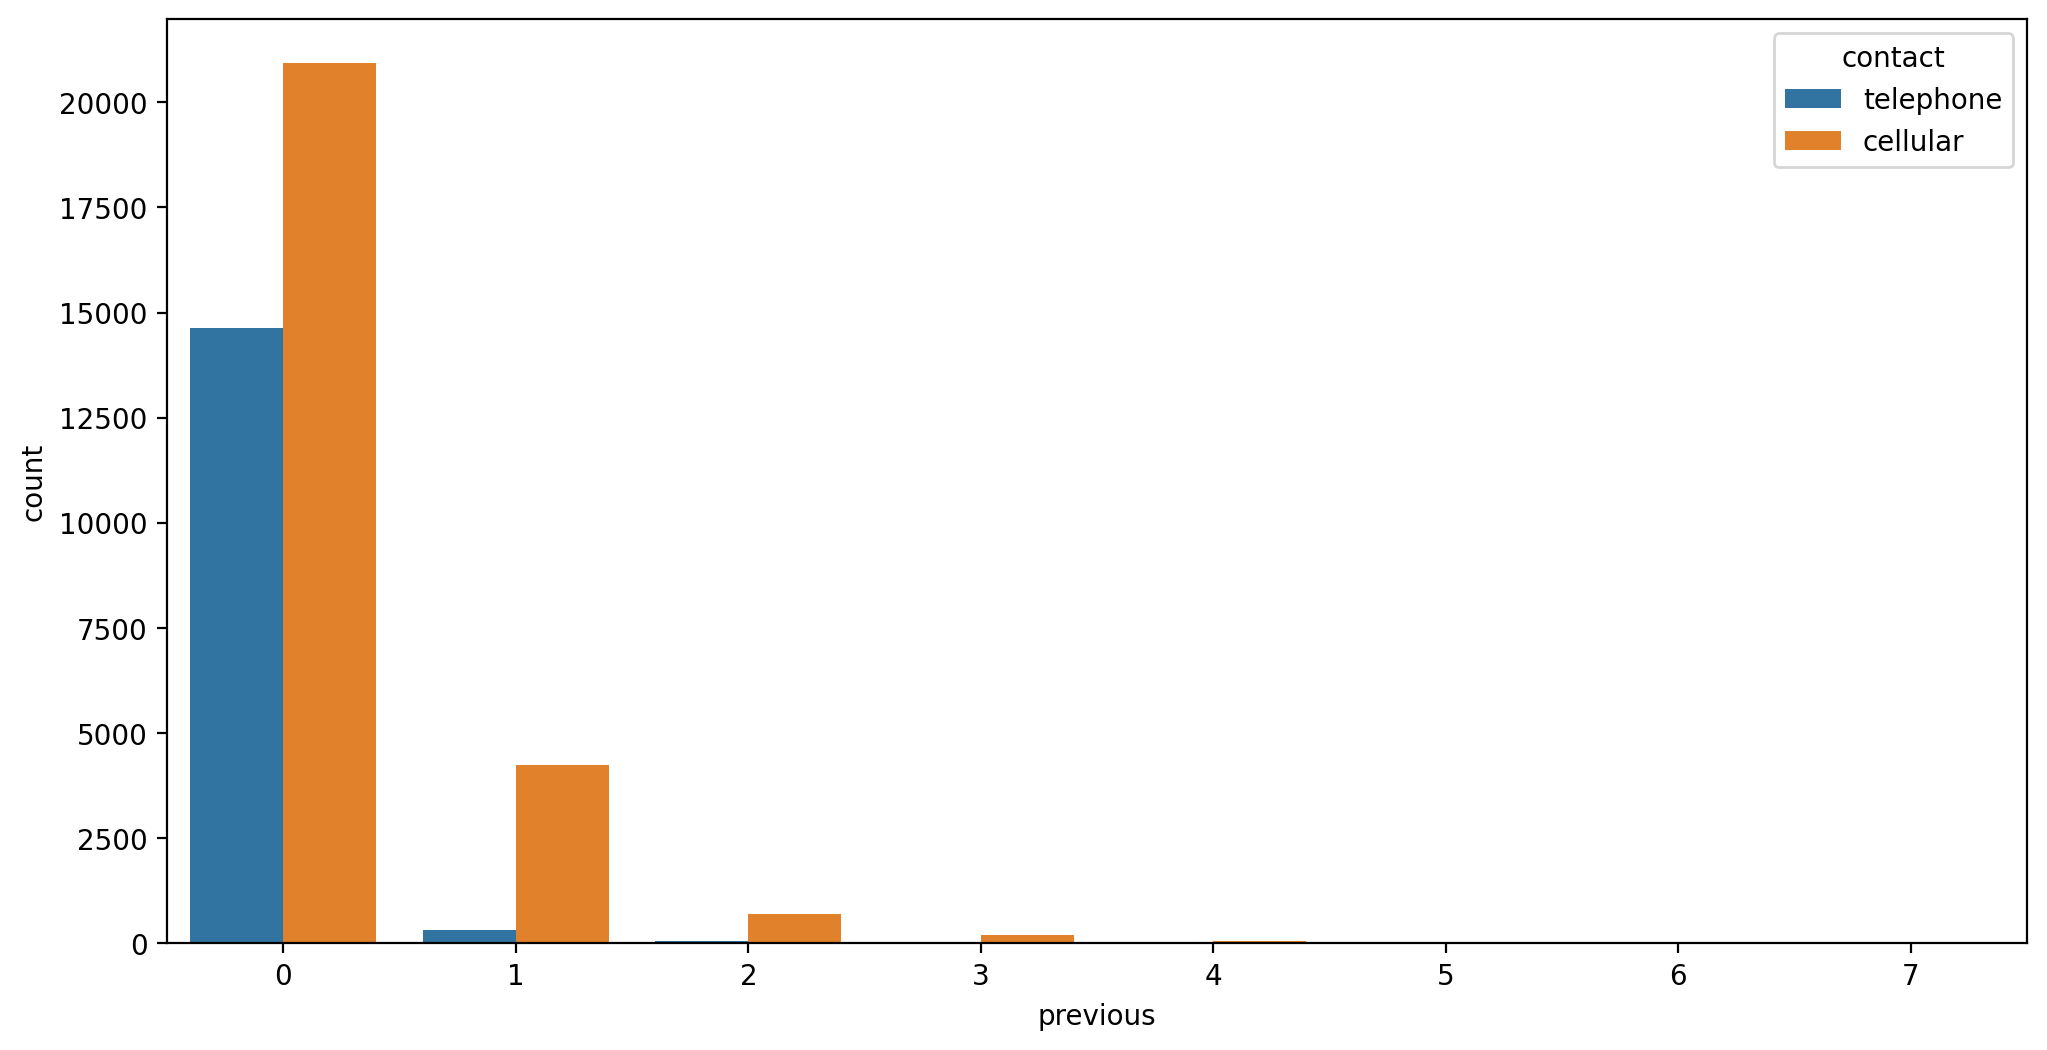

In [69]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(data=df,x='previous',hue='contact')

<Axes: xlabel='previous', ylabel='count'>

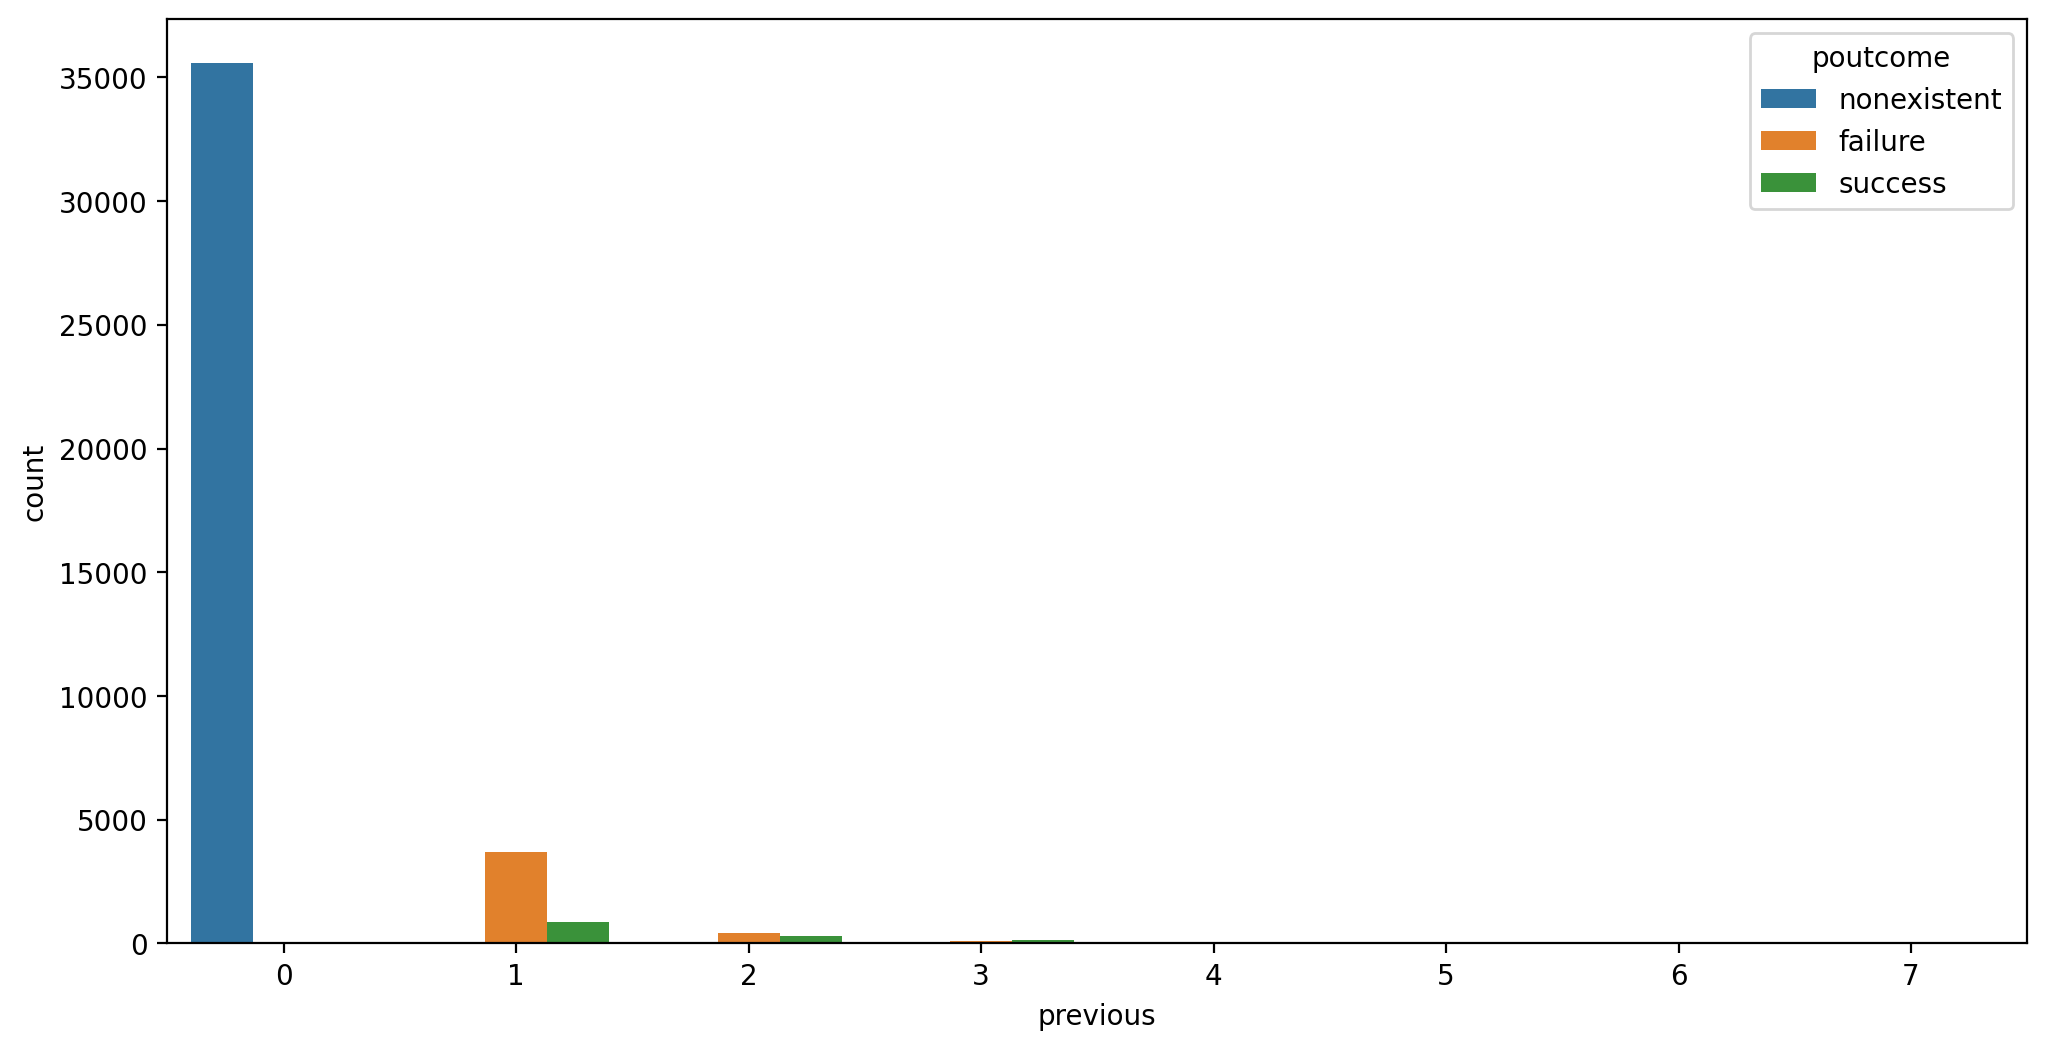

In [70]:
plt.figure(figsize=(12,6),dpi=200)
sns.countplot(data=df,x='previous',hue='poutcome')

## Categorische Features

### Welke job hebben mensen?

In [71]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [72]:
# check hoeveel mensen welk type job hebben:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [73]:
# de indices van de items in deze lijst:
df['job'].value_counts().index

Index(['admin.', 'blue-collar', 'technician', 'services', 'management',
       'retired', 'entrepreneur', 'self-employed', 'housemaid', 'unemployed',
       'student', 'unknown'],
      dtype='object', name='job')

In [74]:
indices = df['job'].value_counts().index

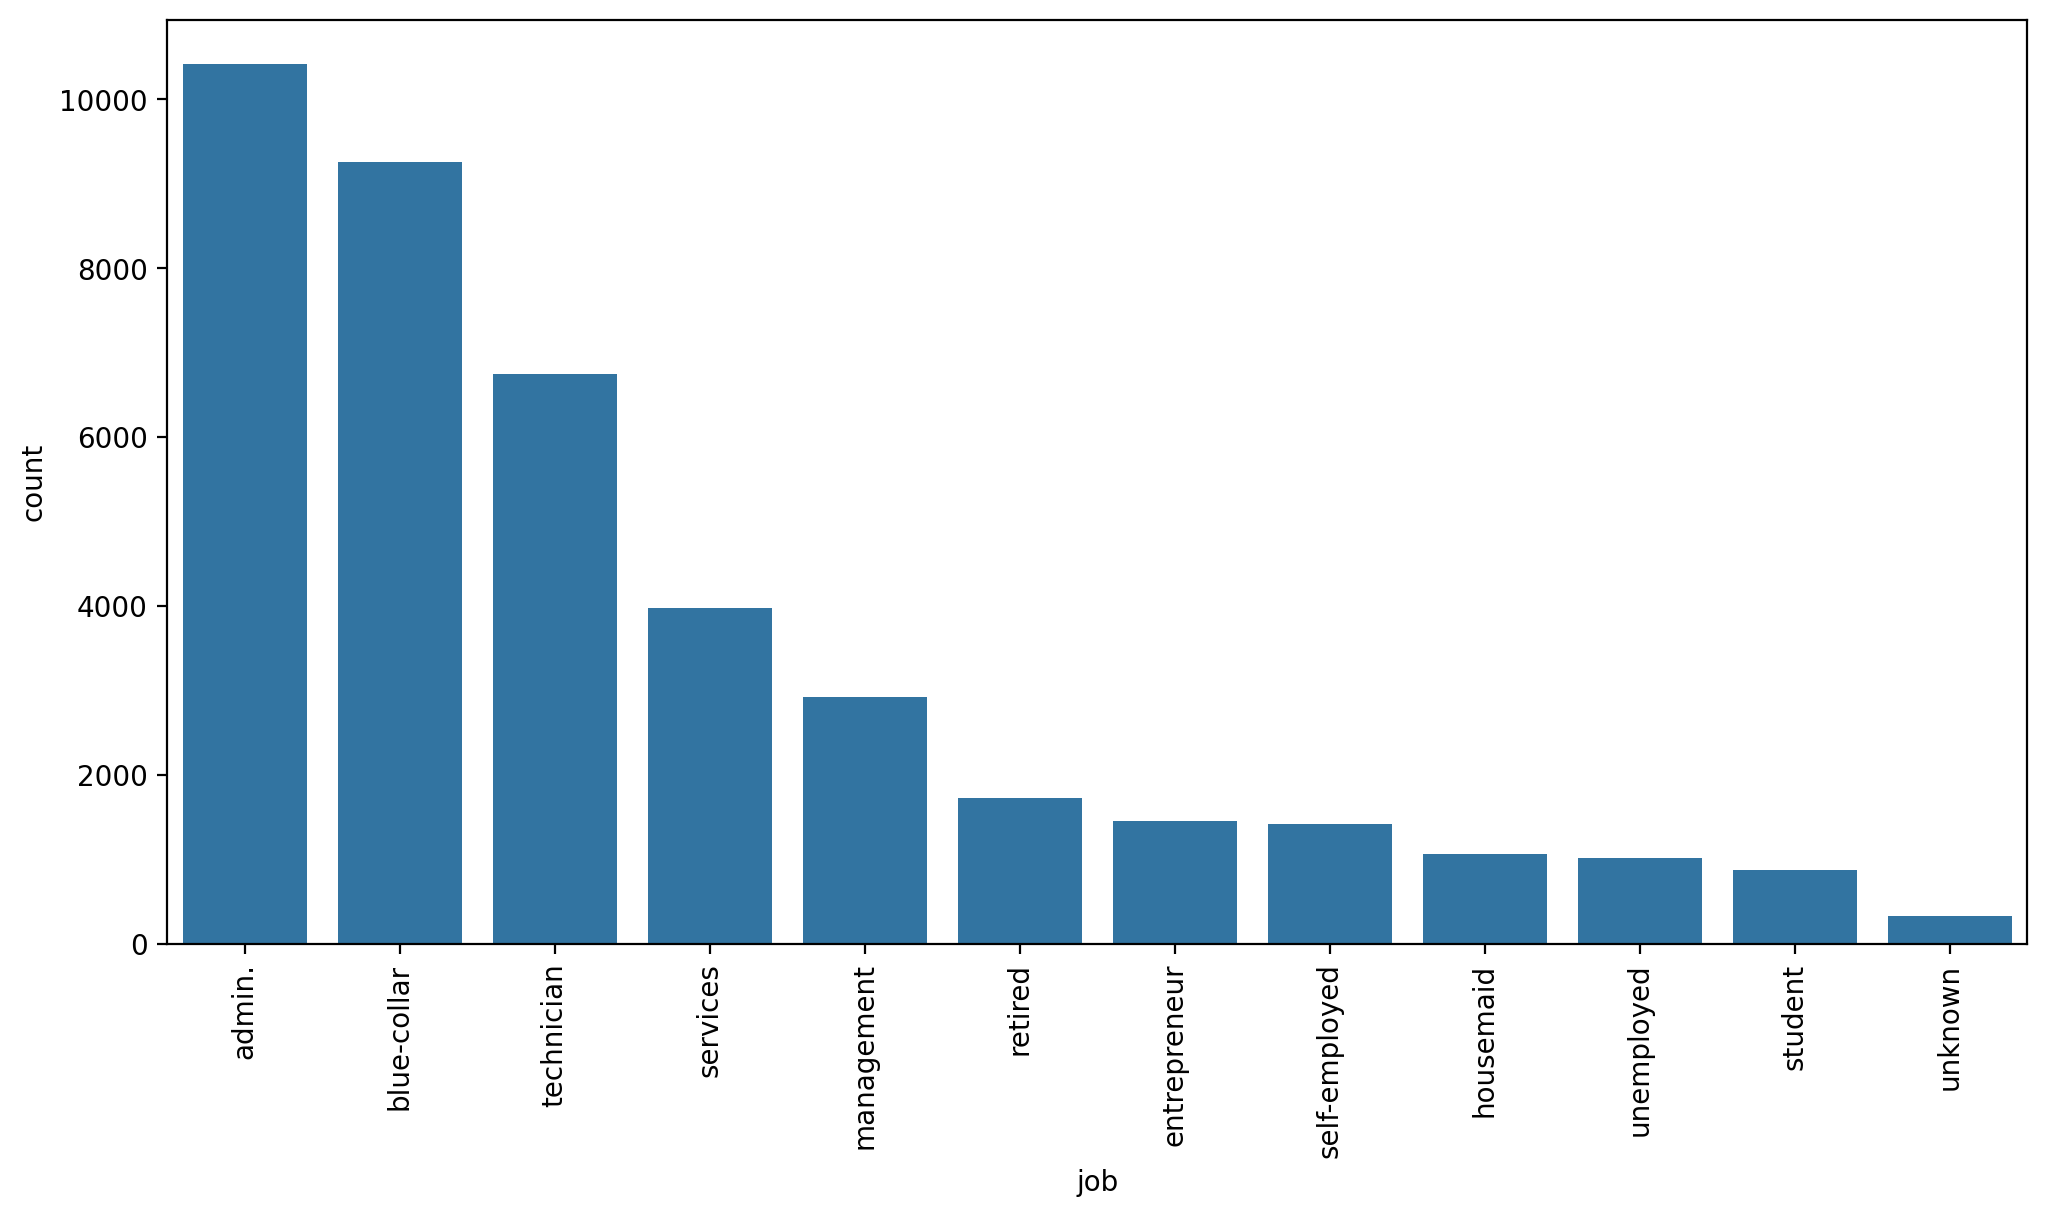

In [75]:
plt.figure(figsize=(12,6),dpi=200)
# https://stackoverflow.com/questions/46623583/seaborn-countplot-order-categories-by-count
sns.countplot(data=df,x='job',order=indices)
plt.xticks(rotation=90);

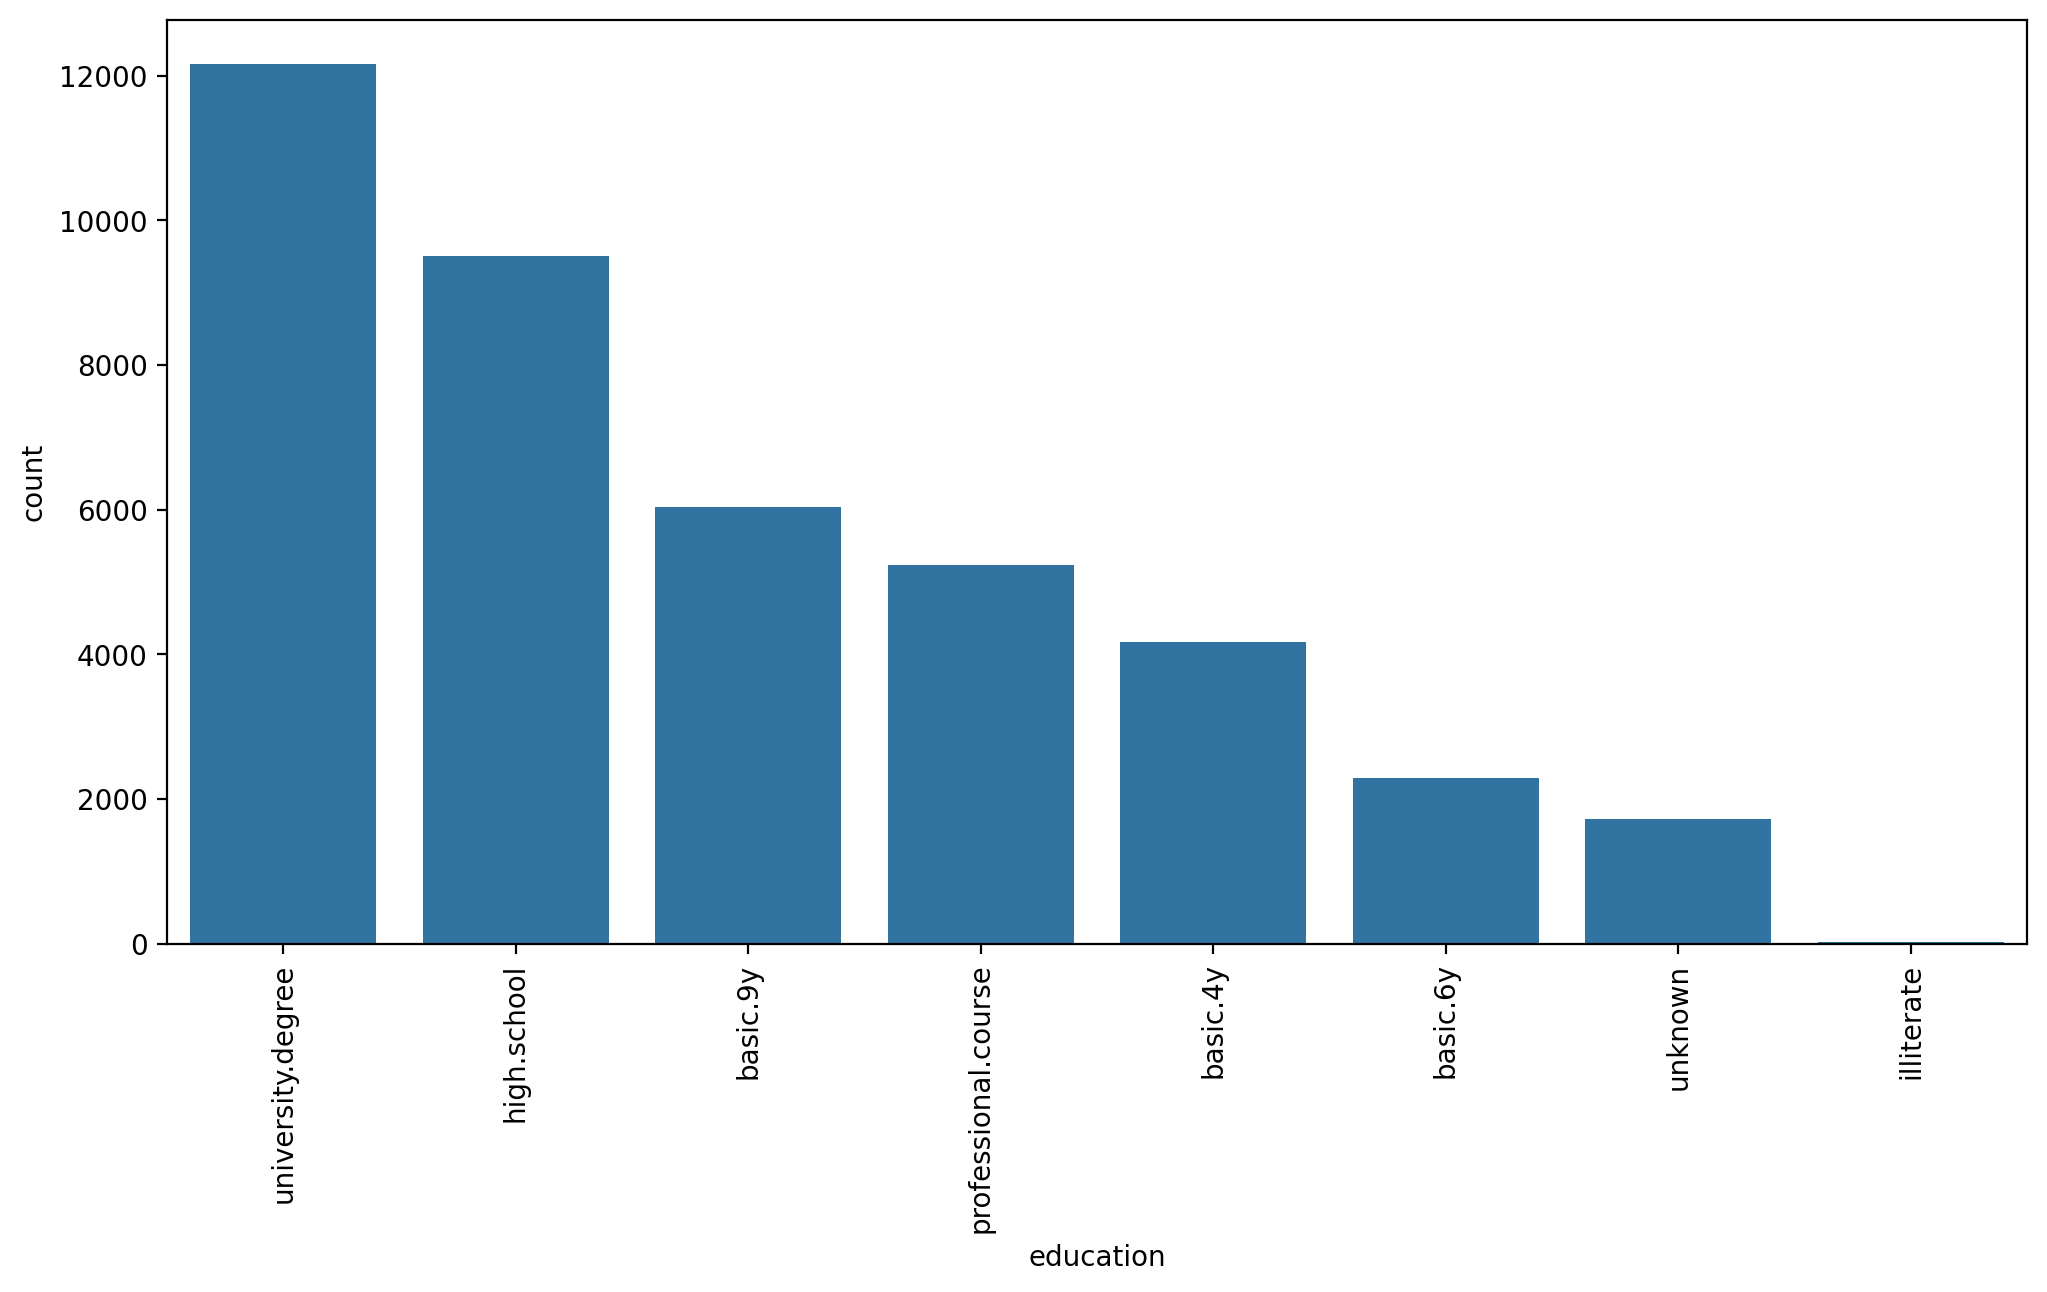

In [76]:
# zelfde voor education:
plt.figure(figsize=(12,6),dpi=200)
# https://stackoverflow.com/questions/46623583/seaborn-countplot-order-categories-by-count
sns.countplot(data=df,x='education',order=df['education'].value_counts().index)
plt.xticks(rotation=90);

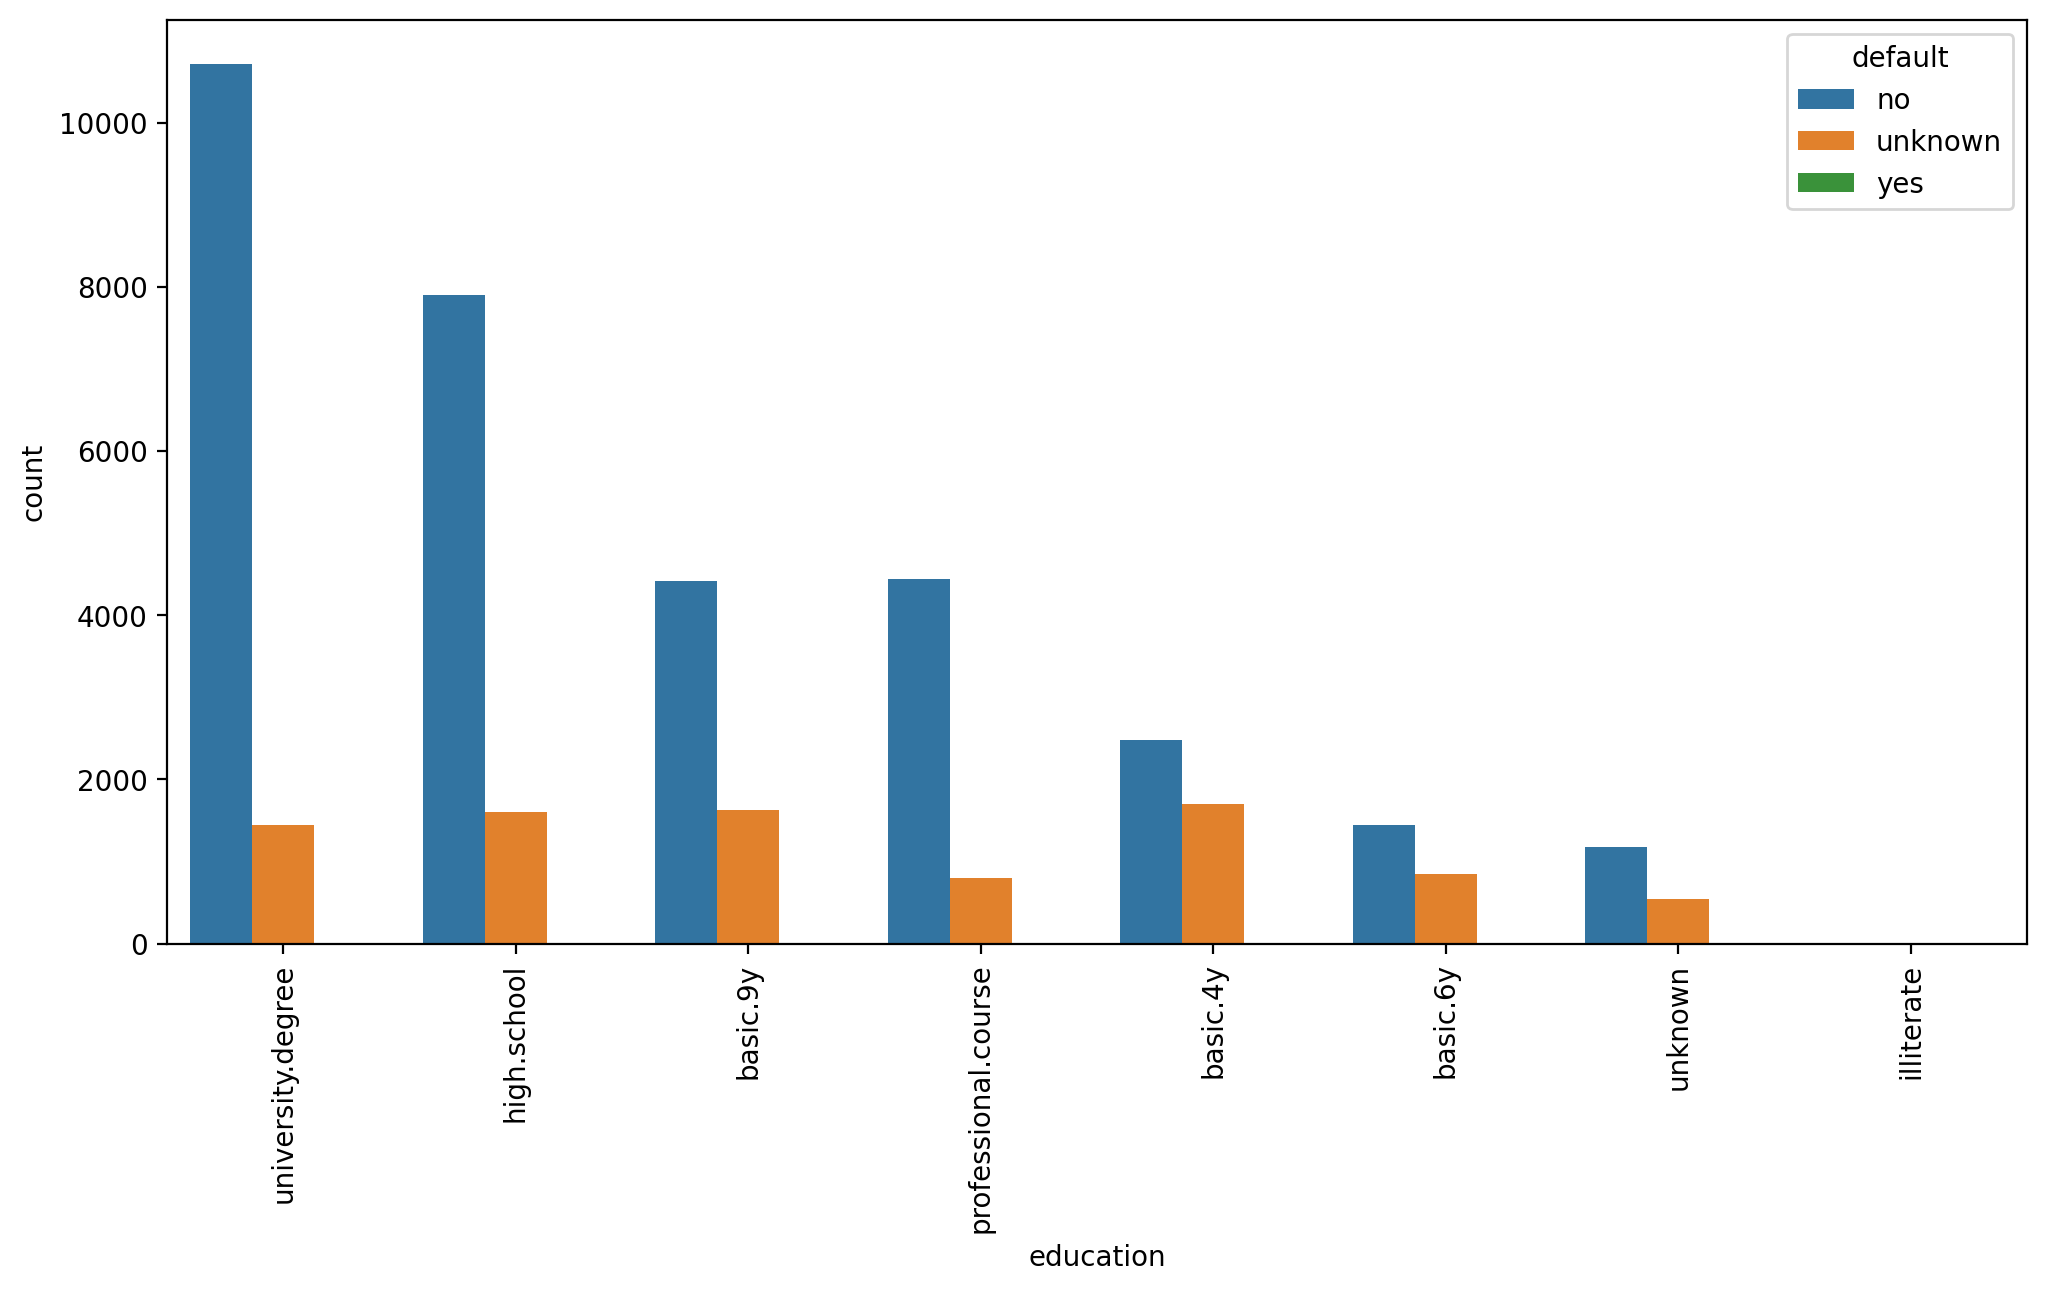

In [77]:
# check of er een verband is tussen opleidingsniveau en het al dan niet terugbetalen van de lening? (defaulted)
plt.figure(figsize=(12,6),dpi=200)
# https://stackoverflow.com/questions/46623583/seaborn-countplot-order-categories-by-count
sns.countplot(data=df,x='education',order=df['education'].value_counts().index,hue='default')
plt.xticks(rotation=90);

Bijna iedereen betaalt lening af - nagenoeg geen defaults! Unknown: of echt ongeweten, of lening loopt nog en is nog niet in status defaulted.

<Axes: xlabel='default', ylabel='count'>

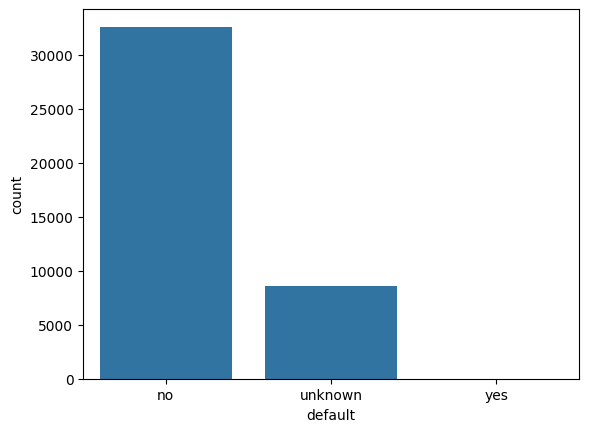

In [78]:
sns.countplot(data=df,x='default')

In [79]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

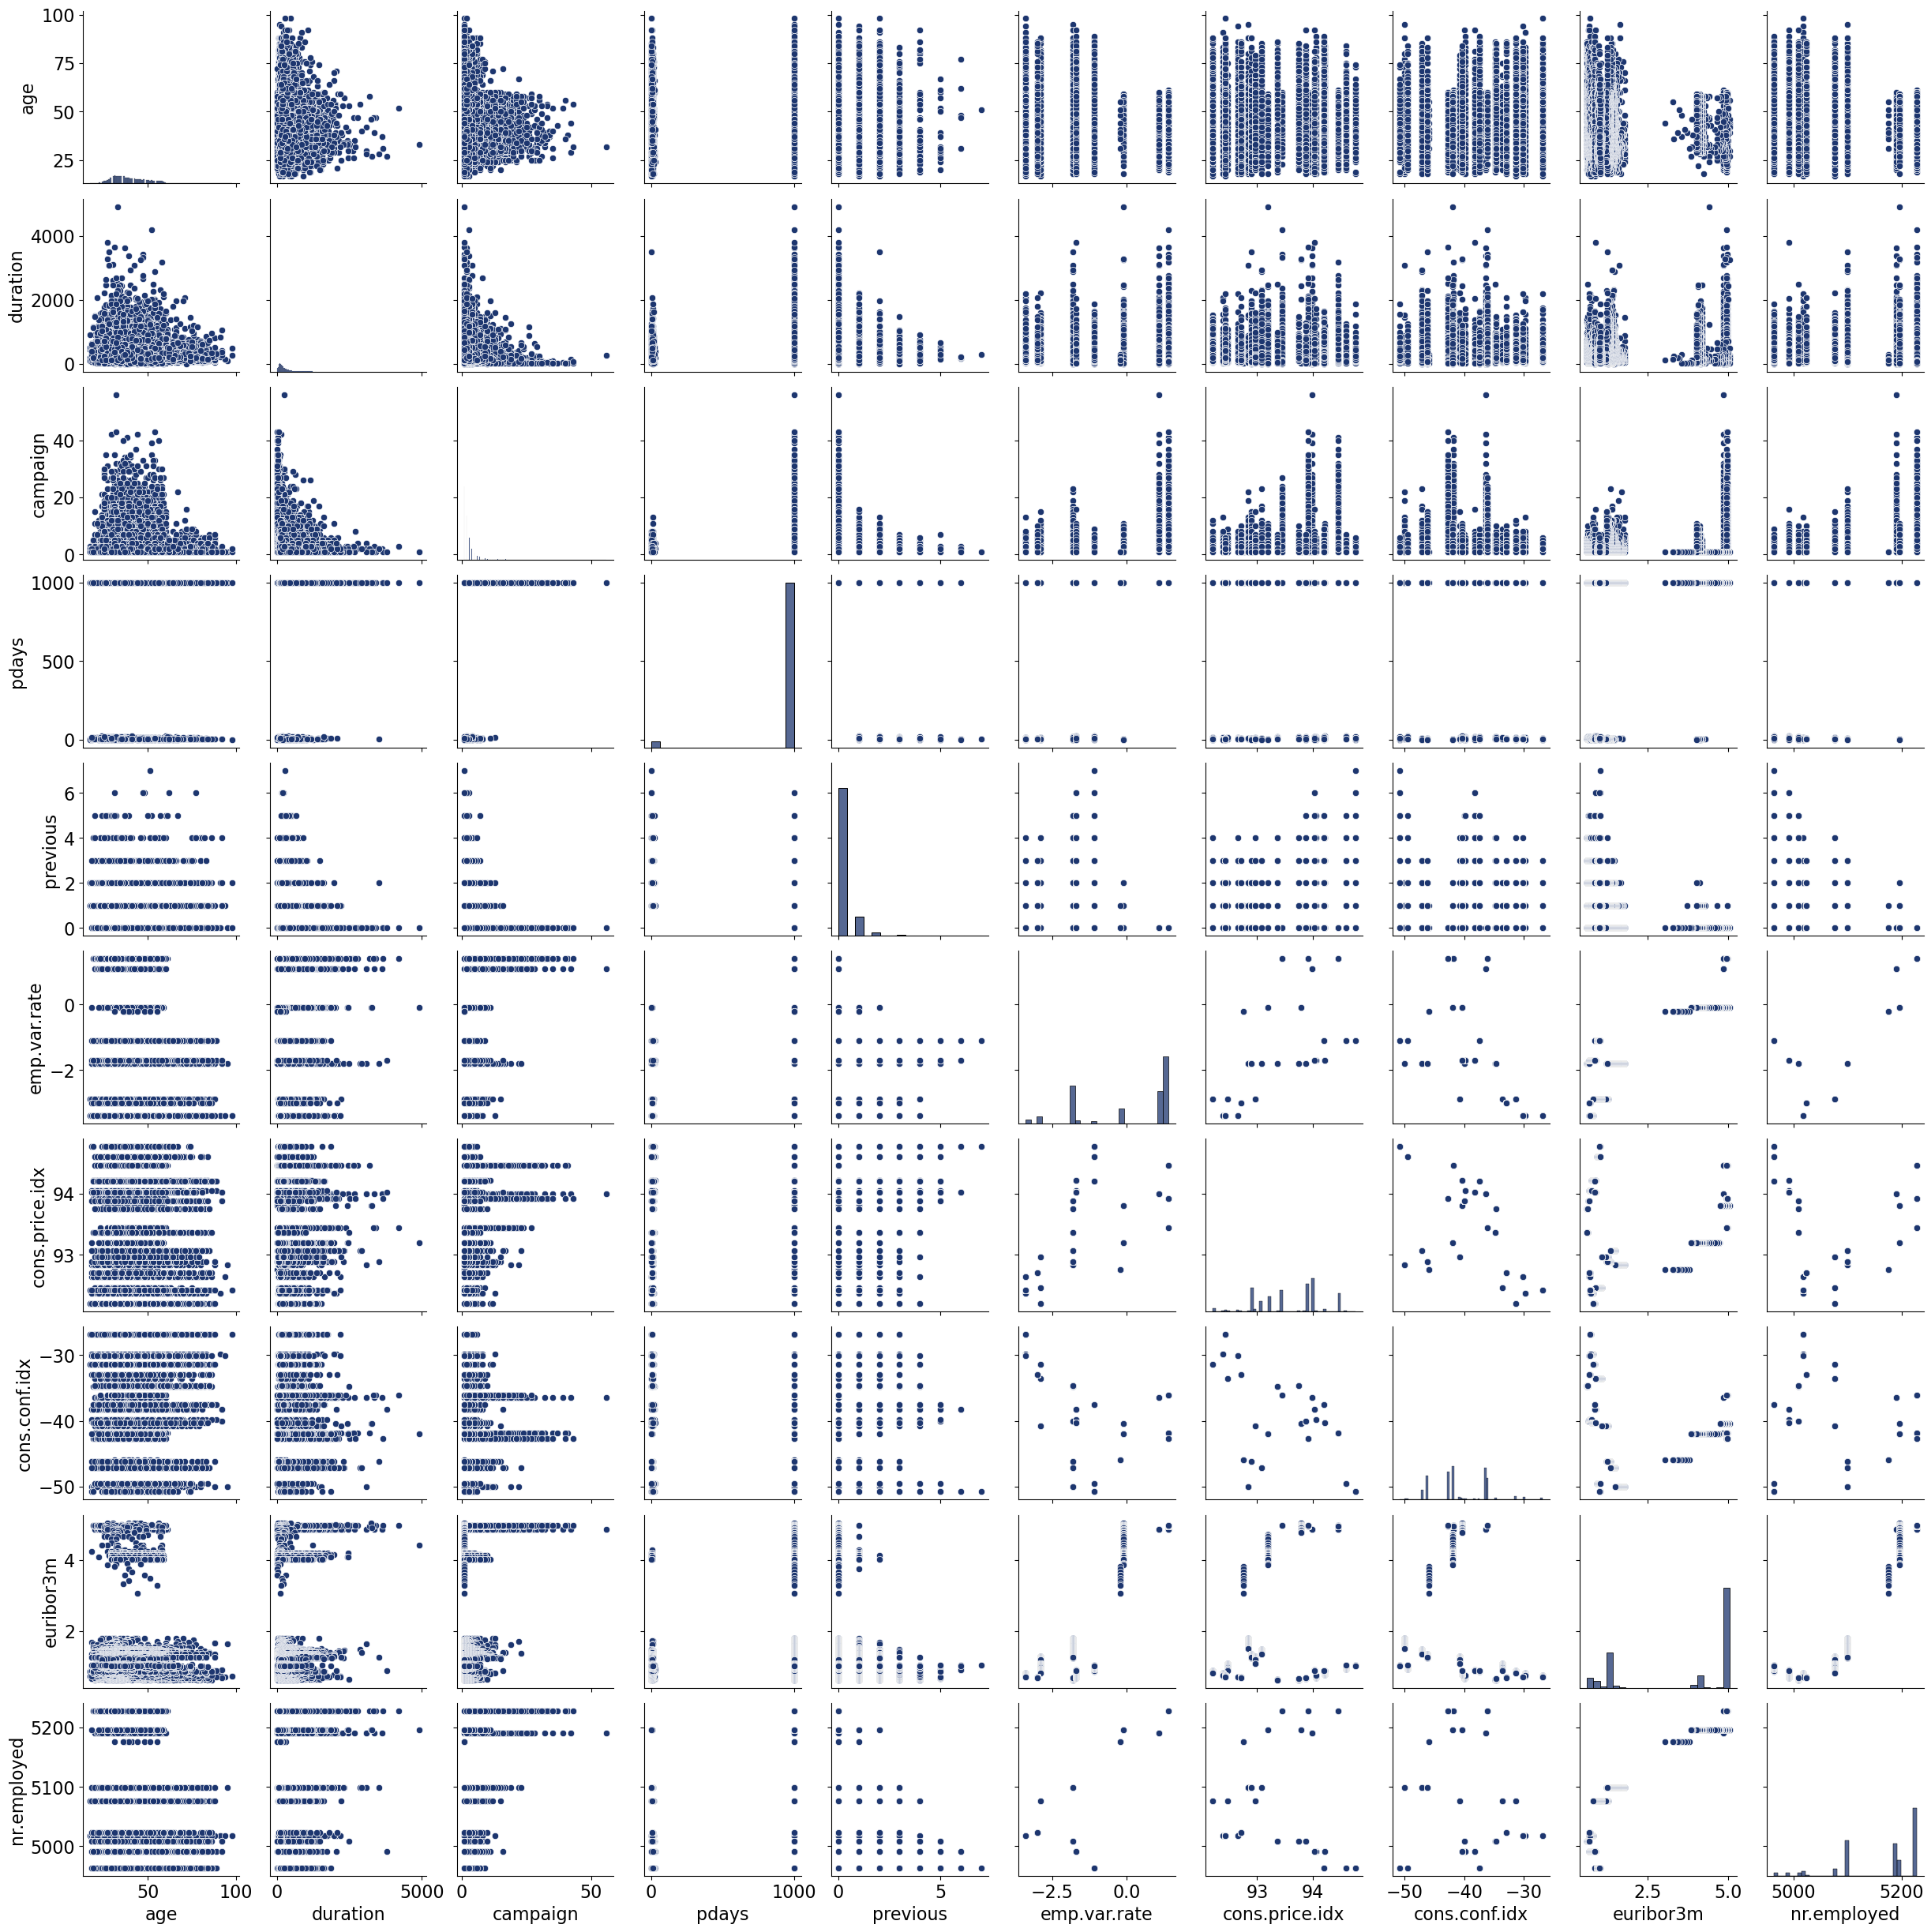

In [81]:
# DIT DUURT LANG! Als je weinig RAM hebt kan je PC ook crashen...
sns.pairplot(df)

## Clustering

### Voorbereiding Data

**UNSUPERVISED LEARNING REMINDER: ER IS GEEN TRAIN TEST SPLIT NODIG WANT ER IS GEEN LABEL OM DE PERFORMANTIE TEGENOVER TE "TESTEN!"**

We moeten echter wel categorische features omzetten naar numerieke waarden waar dat zinvol is.  We kunnen bijvoorbeeld geen afstand meten tussen "housemaid" en "services" maar wel tussen 0 en 1 voor "housemaid" of voor "services"...  We moeten ook de feature gegevens schalen omdat afstand een belangrijke factor is bij clustering.

In [80]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [30]:
X = pd.get_dummies(df)

De dummy variable trap is hier niet van toepassing omdat we geen coëfficiënten berekenen per feature en dus ook niet voor deze dummy variables.  Er is dus geen multicollineariteit.  We moeten dus geen kolom droppen. 

In [31]:
X

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,False,True,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True
41184,46,383,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41185,56,189,2,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,True,False
41186,44,442,1,999,0,-1.1,94.767,-50.8,1.028,4963.6,...,True,False,False,False,False,False,True,False,False,True


In [81]:
from sklearn.preprocessing import StandardScaler

In [82]:
scaler = StandardScaler()

In [83]:
scaled_X = scaler.fit_transform(X)

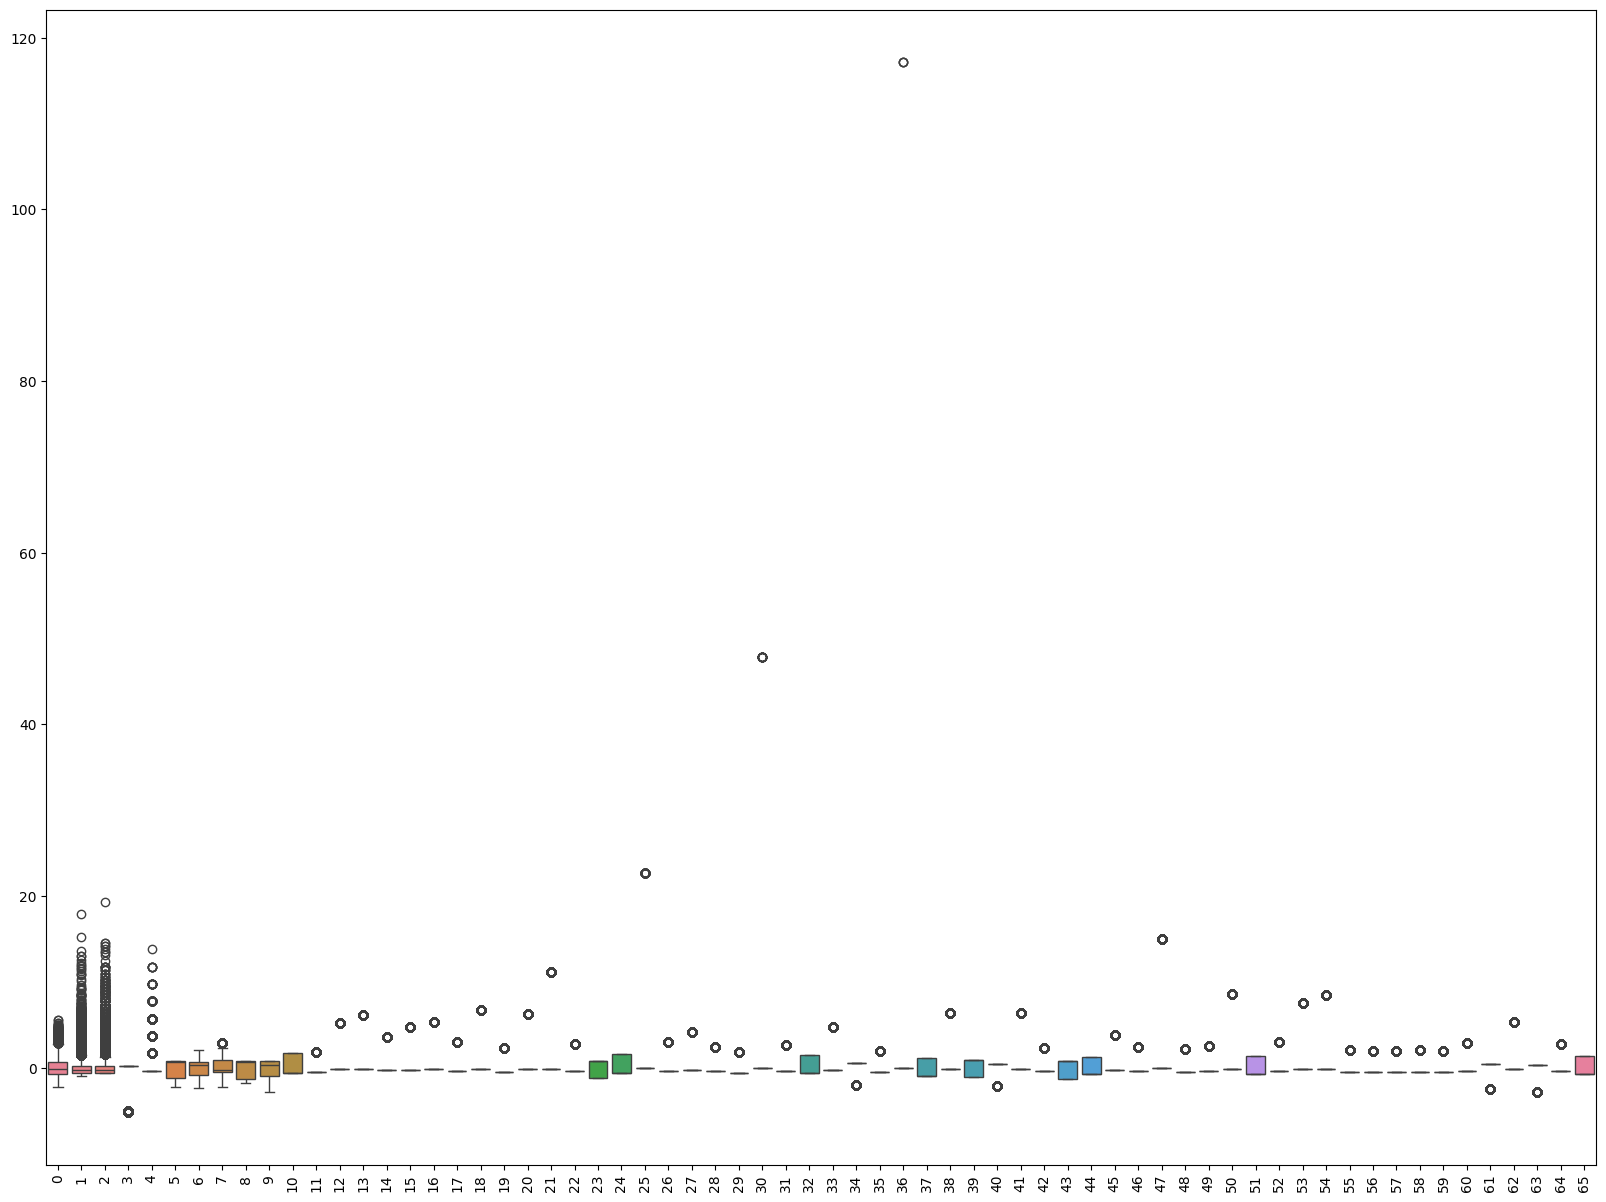

In [84]:
plt.figure(figsize=(20,15))
sns.boxplot(data=scaled_X)
plt.xticks(rotation=90)
plt.show()

### Maken en fitten van een KMeans Model

De methodes:

* fit(X[, y, sample_weight])
    * Bereken centroïden. Tijdens de 'fit'-stap berekent het algoritme de optimale locatie van de centroïden (de centra van de clusters) op basis van de gegeven datapunten. Het probeert de totale afstand van alle punten tot hun dichtstbijzijnde centroïde te minimaliseren. Voor K-means is dit een iteratief proces waarbij de centroïden in eerste instantie willekeurig worden gekozen en vervolgens worden verplaatst naar het gemiddelde van de punten die eraan zijn toegewezen, totdat de locatie van de centroïden niet meer significant verandert.

* fit_predict(X[, y, sample_weight])
    * Fit: zie hierboven. Predict: Na het bepalen van de locatie van de centroïden, voorspelt het algoritme voor elk datapunt tot welke cluster het behoort door het te koppelen aan de dichtstbijzijnde centroïde. De fit_predict methode combineert deze twee stappen en geeft voor elk datapunt in de dataset een clusterindex terug. Deze index vertegenwoordigt de cluster waaraan het datapunt is toegewezen.

* fit_transform(X[, y, sample_weight])
    * (gaan we niet gebruiken) Bereken clusters en transformeer X naar een cluster-afstandsruimte.  De gegevens worden hierbij getransformeerd naar een ruimte waar de afstanden tussen de verschillende clusters de belangrijkste kenmerken zijn. Elk datapunt wordt getransformeerd naar een representatie gebaseerd op zijn afstand tot de centra van de clusters in plaats van op zijn oorspronkelijke kenmerken. Dit is vaak een stap in de verwerking van gegevens bij clusteringalgoritmes zoals K-means, waarbij men probeert om de datapunten te groeperen op basis van hun onderlinge gelijkenis.

* predict(X[, sample_weight])
    * De predict methode in het KMeans clustering algoritme wordt gebruikt nadat het model is getraind met behulp van de fit methode. De predict methode doet het volgende: Het neemt nieuwe gegevenspunten (of dezelfde punten waarop het model getraind is) en wijst elk van hen toe aan de dichtstbijzijnde cluster die tijdens de training is gevonden. Het doet dit door de afstand van elk punt tot elk van de centroïden te berekenen en het punt toe te wijzen aan de cluster met de dichtstbijzijnde centroïde. De uitvoer van predict is een array van clusterindices. Elk element in deze array geeft aan tot welke cluster het corresponderende datapunt is toegewezen.

In [85]:
from sklearn.cluster import KMeans # HOOFDLETTER K en M!

In [89]:
# help(KMeans)

## De belangrijkste parameters:

-**n_clusters** is belangrijkste parameter.  default: 8 clusters.  Dit is eigenlijk zinloos, want dit hangt volledig af van de dataset.  Deze waarde kan dus onredelijk zijn.  

**Andere settings:** 

-**'random'**: kies de initiële punten random; je zou deze ook zelf kunnen kiezen en er is de mogelijkheid om een seed te gebruiken voor de random selectie van punten.  
-**'max_iter'**:  KMeans zou in een loop kunnen komen waarbij punten bijna exact tussen 2 clusters vallen en continu tussen 2 clusters swappen of zo.  Default is 300 iteraties, maar voor heel grote datasets (100.000 punten of zo) kan max_iter omhoog.  
-**'precompute_distances'** kan ook aangepast worden: dit is de manier waarop afstanden tussen punten worden berekend; laat dit best op 'auto'.

-**'n_init'** in KMeans specificeert het aantal keer dat het algoritme zal worden uitgevoerd met een verschillende willekeurige initiële centroid seed. Het algoritme wordt meerdere keren uitgevoerd om de waarschijnlijkheid te verkleinen dat het eindresultaat een suboptimaal clustering is vanwege een ongelukkige initiële keuze van centroids.  Door n_init op een hoger getal in te stellen, verhoog je de kans dat KMeans de meest optimale clustering vindt. Het vergt echter ook meer rekenwerk, omdat het algoritme meerdere keren moet worden uitgevoerd. Vanaf versie 1.4 van sklearn is er een 'auto' waarde die als optimaal wordt beschouwd.

In [86]:
model = KMeans(n_clusters=2, n_init='auto')  
# momenteel geen idee van aantal clusters
# maar 2 is gewoon een keuze: mensen waarnaar ik marketing wil doen,
# en mensen waarbij dit niet het geval is... 

In [87]:
cluster_labels = model.fit_predict(scaled_X)

In [88]:
# BELANGRIJK: JOUW 0 en 1 kan het omgekeerde zijn van bij mij. 
# Deze cluster nummers zijn niet van betekenis: belangrijk is dat 
# ze aan dezelfde cluster worden toegewezen.  Het nummer is willekeurig 
# gekozen... Als je meermaals runt krijg je andere nummers! Als je dit
# wil vermijden: random state vb 101, dan blijven de nummers identiek.
cluster_labels

array([1, 1, 1, ..., 0, 0, 0], dtype=int32)

In [89]:
len(scaled_X)

41188

In [90]:
len(cluster_labels)

41188

In [91]:
# het cluster label toevoegen aan de originele data
X['Cluster'] = cluster_labels

In [92]:
X.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success,subscribed_no,subscribed_yes,Cluster
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,False,True,False,True,False,1


Hoe kunnen we dit nu interpreteren?  We zouden kunnen nagaan hoe sterk features zijn gecorreleerd met clusters. We weten nog niet of K=2 een goede keuze was, maar het is een goed idee om na te gaan of er een correlatie is tussen bepaalde features en de cluster waar ze zijn aan toegewezen.

**pearson correlation coëfficient** -> hoe sterk is de correlatie tussen # elke feature en de cluster toewijzing
X.corr() 

Vraag nu enkel de cluster kolom.  Dit geeft van elke feature weer hoe sterk de correlatie met de cluster toewijzing is.  Dit betekent dat in dit geval, met K=2, je kan nagaan naar welke features vooral wordt gekeken om te bepalen tot welke cluster een observatie hoort.
X.corr()['Cluster']

We willen niet de correlatie met zichzelf, dus we gebruiken integer position based iloc om te slicen.  Je moet hierbij rijen en kolommen specifiëren met hun integer posities.
X.corr()['Cluster'].iloc[:-1]

In [93]:
X.corr()['Cluster'].iloc[:-1]

age                     0.019659
duration               -0.040051
campaign                0.129101
pdays                   0.267686
previous               -0.478442
                          ...   
poutcome_failure       -0.464271
poutcome_nonexistent    0.544348
poutcome_success       -0.254379
subscribed_no           0.294748
subscribed_yes         -0.294748
Name: Cluster, Length: 65, dtype: float64

Spiegelbeeld-effect van vb subscribed_no en subscribed_yes: dit effect treedt op omdat de som van de correlaties met elk van de dummyvariabelen die uit dezelfde oorspronkelijke variabele zijn afgeleid, nul moet zijn (ervan uitgaande dat er geen andere categorieën zijn). Dit komt omdat de dummyvariabelen perfect negatief gecorreleerd zijn met elkaar - als de ene stijgt, moet de andere dalen, omdat elke observatie ofwel een 0 of een 1 moet zijn voor elke dummyvariabele afgeleid van dezelfde oorspronkelijke categorische variabele.

Dit fenomeen is een goed voorbeeld van waarom het belangrijk is om de context van je data en de aard van dummyvariabelen te begrijpen wanneer je correlatieanalyses uitvoert.

In [94]:
# welke features hebben de sterkste correlatie?  Sorteren!
X.corr()['Cluster'].iloc[:-1].sort_values()

previous               -0.478442
poutcome_failure       -0.464271
contact_cellular       -0.410508
month_apr              -0.357904
subscribed_yes         -0.294748
                          ...   
poutcome_nonexistent    0.544348
cons.price.idx          0.679394
nr.employed             0.886120
emp.var.rate            0.932603
euribor3m               0.959267
Name: Cluster, Length: 65, dtype: float64

Zowel de bovenste als de onderste hebben de sterkste absolute waarde voor correlatie!  We kunnen dit plotten:

<Axes: >

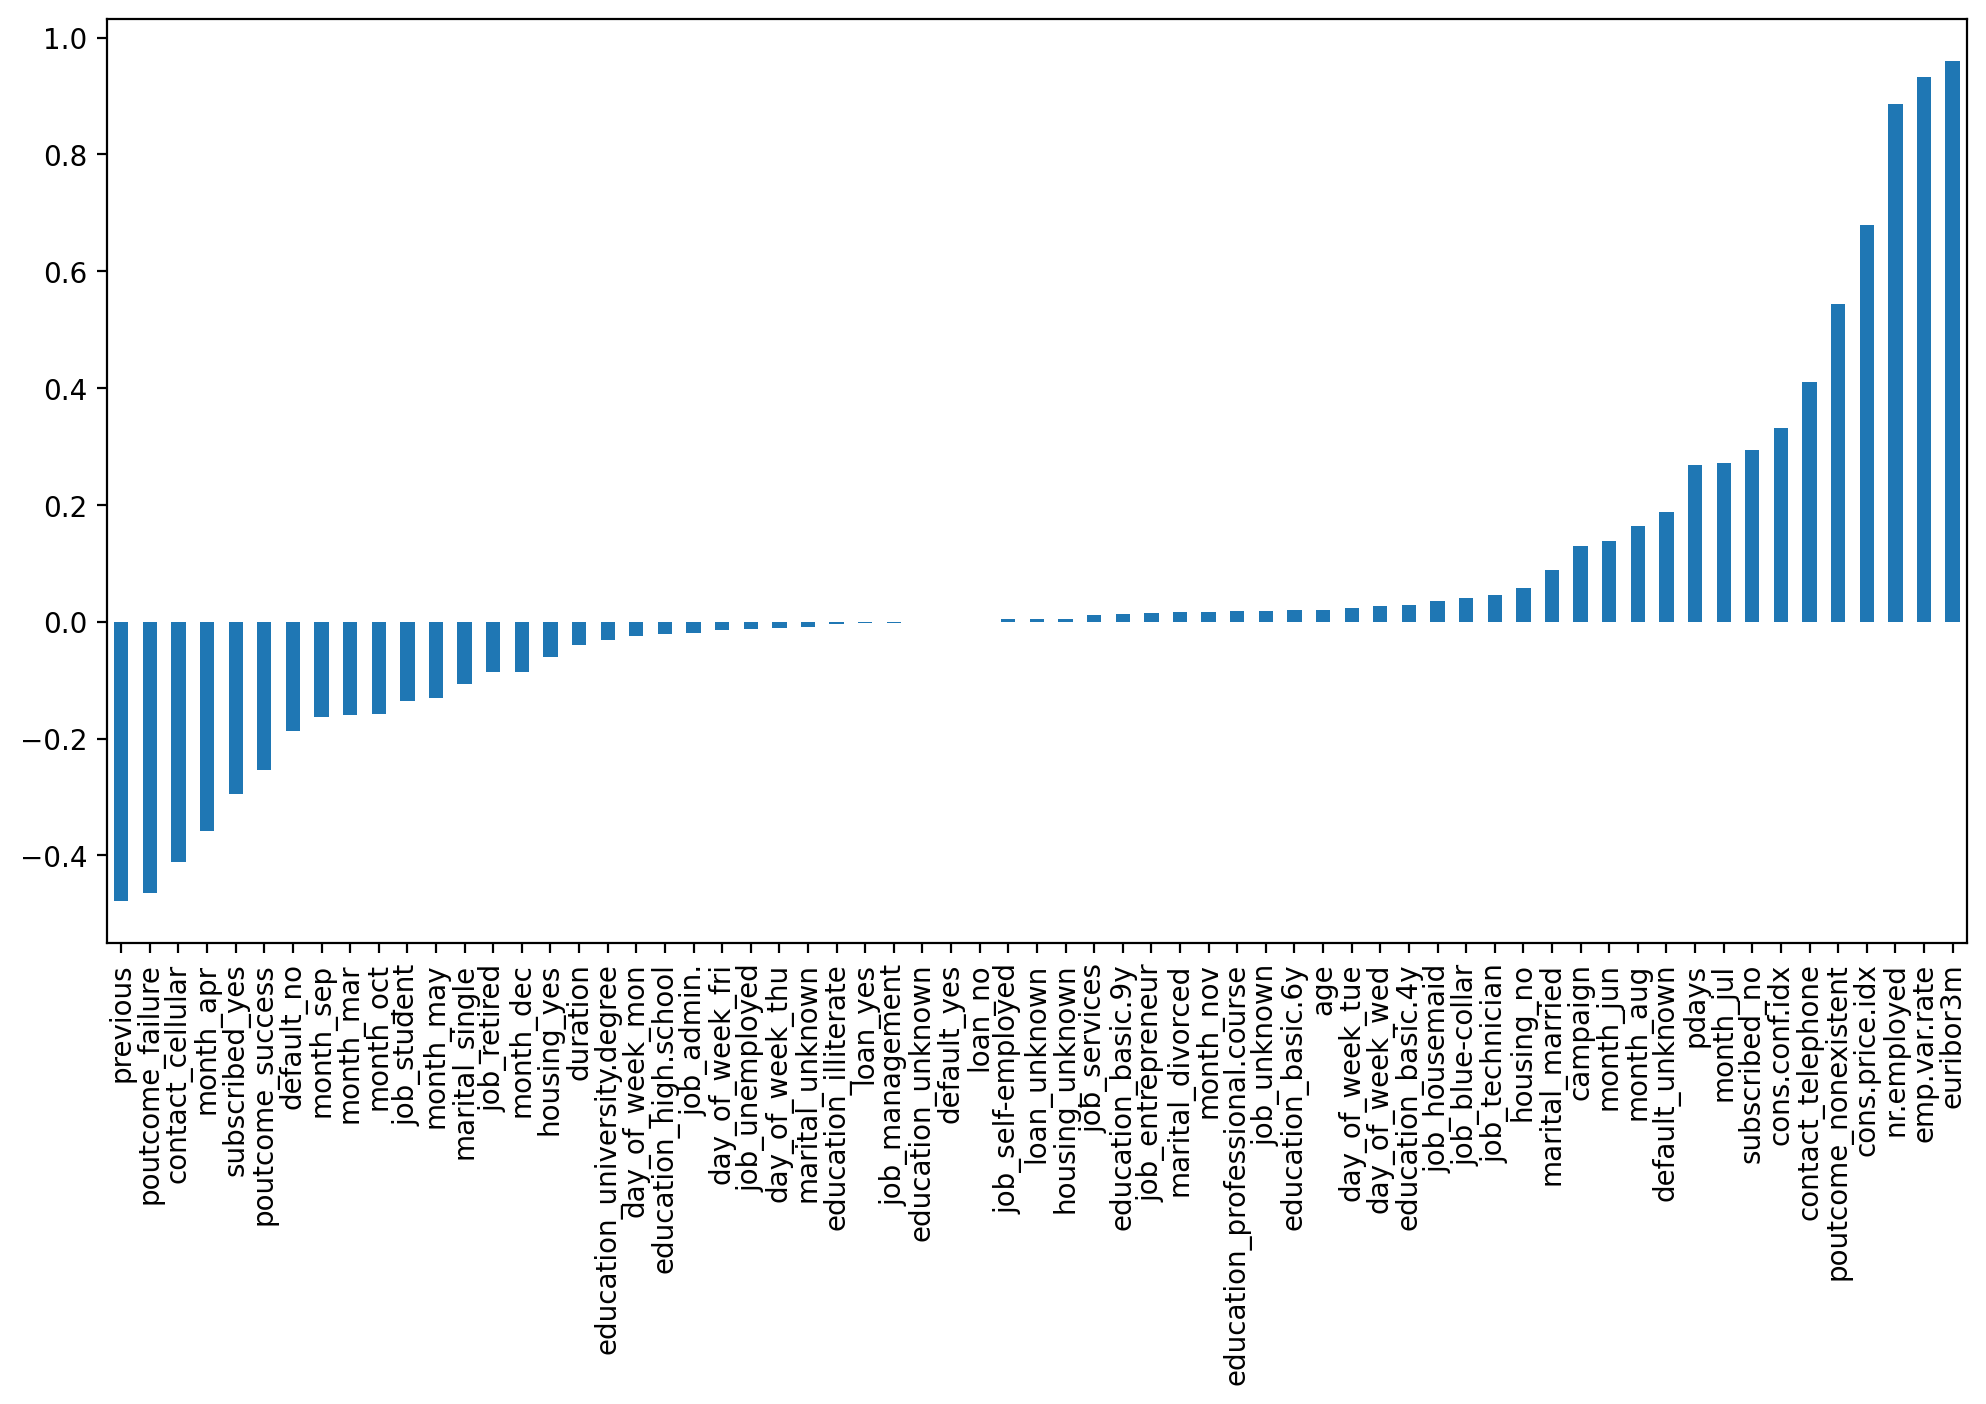

In [95]:
plt.figure(figsize=(12,6),dpi=200)
X.corr()['Cluster'].iloc[:-1].sort_values().plot(kind='bar')

Nu je weet welke features belangrijk zijn om de cluster te bepalen: praat met een domein expert!

## Terug naar de theorie!

------------------------------------------------------------------------------

## Kiezen van een waarde voor K

In [100]:
import numpy as np

npoints = 10
ssd = []

clusters_X = np.zeros((scaled_X.shape[0], npoints-2))

for k in range(2, npoints):    
    model = KMeans(n_clusters=k, n_init=50)    
    model.fit(scaled_X)    
    #SSD van de samples tot hun centroïde
    ssd.append(model.inertia_) # SSD == .inertia_
    cluster_labels = model.fit_predict(scaled_X)
    clusters_X[:, k-2] = cluster_labels

# Attach the cluster labels to the original X matrix
for i in range(2, npoints):
    X[f'Cluster_{i}'] = clusters_X[:, i-2]



    

In [101]:
import pandas as pd
import plotly.express as px

# Extract the centroids for Cluster_6
centroids_df = X.groupby('Cluster_6')[['age', 'duration', 'previous']].mean().reset_index()

# Create the parallel plot
fig = px.parallel_coordinates(centroids_df, color='Cluster_6', dimensions=['age', 'duration', 'previous'])
fig.show()

In [104]:
import pandas as pd
import plotly.express as px

# Create the parallel plot
fig = px.parallel_coordinates(X, color='Cluster_6', dimensions=['Cluster_6', 'age', 'duration', 'previous'])
fig.show()

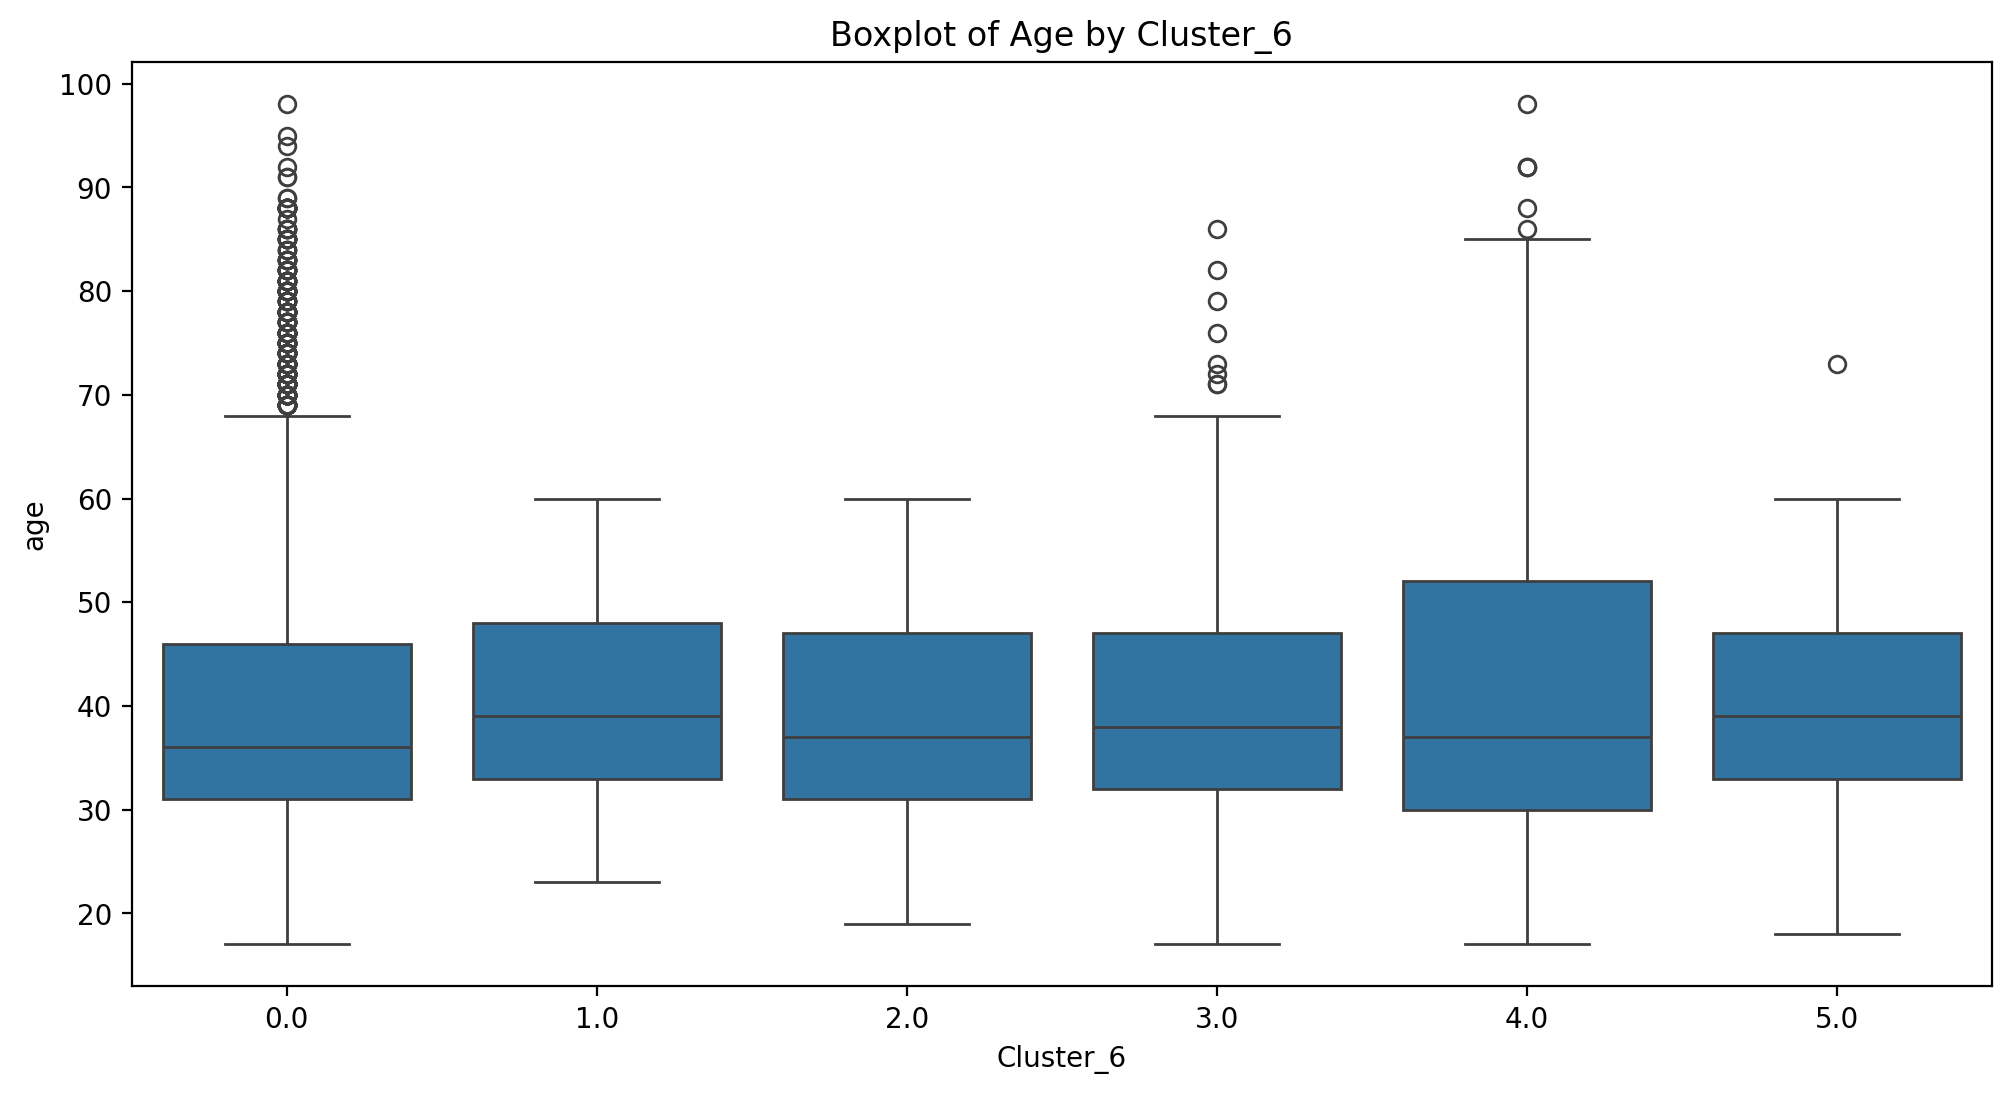

In [105]:
plt.figure(figsize=(12, 6), dpi=200)
sns.boxplot(data=X, x='Cluster_6', y='age')
plt.title('Boxplot of Age by Cluster_6')
plt.show()

Text(0, 0.5, ' Sum of Squared Distances')

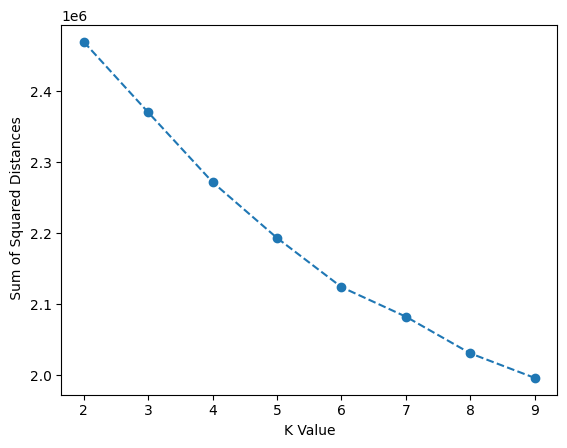

In [97]:
plt.plot(range(2,npoints),ssd,'o--')
plt.xlabel("K Value")
plt.ylabel(" Sum of Squared Distances")

K = 6 ziet er een goede waarde uit!

Analyse van de reductie van SSE

In [49]:
ssd

[2469792.361662753,
 2370416.2957137655,
 2271502.7007717732,
 2200694.1782342284,
 2145495.143478034,
 2081017.0326628587,
 2031383.6315690405,
 1986760.930392371]

In [98]:
# Wijziging in SSD 
# Opgepast: de indexen zijn niet echt K waarden maar de 
# indexen van het verschil in SSD.  Als je een grote drop
# ziet bij index 5 dan is dit de sprong naar K=6!
pd.Series(ssd).diff()

0             NaN
1   -99344.283036
2   -98465.480526
3   -78554.135227
4   -69259.754800
5   -41681.259186
6   -51699.509953
7   -34629.493673
dtype: float64

<Axes: >

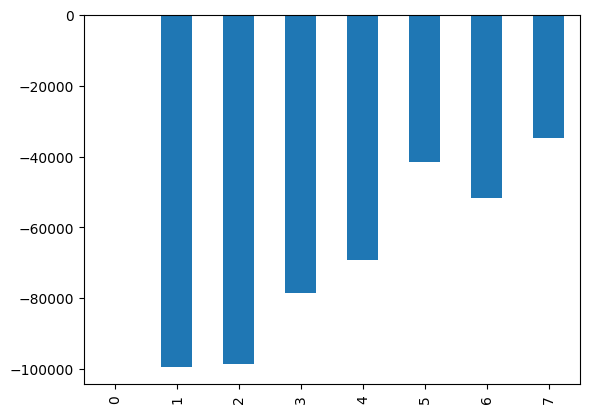

In [99]:
pd.Series(ssd).diff().plot(kind='bar')